# **Python for Data Science Final Project**  
## Group 5: Magdalena, Francois, Bianca, Marcos, Enric A 
### Professors: Javier Martín, Marçal García

---

## **Libraries**
Below you will find all the required libraries that we used to solve the exercie.

---

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.ticker import FuncFormatter

## **Loading the Datasets** 
Below you will see all the Datasets that we will be working on.

---

In [5]:
folder_path = r"C:\Users\enric\OneDrive - Universitat Ramón Llull\ESADE\Term 1\Python for Data Science\Final\Team_5"

# Dictionary mapping the company names to the corresponding file names
dataset_files = {
    "Berkshire Hathaway Inc. (BRK-A)": "BRK-A.csv",
    "Krispy Kreme, Inc. (DNUT)": "DNUT.csv",
    "Domino’s Pizza, Inc. (DPZ)": "DPZ.csv",
    "Luckin Coffee Inc. (LKNCY)": "LKNCY.csv",
    "McDonald’s Corporation (MCD)": "MCD.csv",
    "Papa John’s International, Inc. (PZZA)": "PZZA.csv",
    "Restaurant Brands International, Inc. (QSR)": "QSR.csv",
    "Starbucks Corporation (SBUX)": "SBUX.csv",
    "The Wendy’s Corporation (WEN)": "WEN.csv",
    "Yum! Brands, Inc. (YUM)": "YUM.csv"
}

# Loading the datasets into a dictionary
datasets = {}
for name, file in dataset_files.items():
    datasets[name] = pd.read_csv(f"{folder_path}\\{file}")






## **Pre-Analysis**

Before solving the exercises, we explored the datasets to understand their structure and contents.


### **1) Check for Missing Data**

In this section we aim to analyze the missing data of each dataset and solve the issue.

---

In [6]:
for name, df in datasets.items():
    total_rows = len(df)  # Total rows 
    missing_count = df.isnull().sum()  # Missing values for each column in (numbers)
    missing_percentage = (missing_count / total_rows * 100).round(2)  # Missing values for each column in (%)

    print(f"Dataset: {name}")
    print("Missing Values (in numbers):")
    print(missing_count)  
    print()
    
    print("Missing Values (in % compared to the total dataset):")
    print(missing_percentage)  
    print("-" * 50)  



Dataset: Berkshire Hathaway Inc. (BRK-A)
Missing Values (in numbers):
Date           0
Open         550
High         545
Low          554
Close        545
Adj Close    545
Volume       562
dtype: int64

Missing Values (in % compared to the total dataset):
Date         0.00
Open         4.90
High         4.85
Low          4.93
Close        4.85
Adj Close    4.85
Volume       5.01
dtype: float64
--------------------------------------------------
Dataset: Krispy Kreme, Inc. (DNUT)
Missing Values (in numbers):
Date          0
Open         39
High         39
Low          40
Close        38
Adj Close    40
Volume       40
dtype: int64

Missing Values (in % compared to the total dataset):
Date         0.00
Open         4.79
High         4.79
Low          4.91
Close        4.66
Adj Close    4.91
Volume       4.91
dtype: float64
--------------------------------------------------
Dataset: Domino’s Pizza, Inc. (DPZ)
Missing Values (in numbers):
Date           0
Open         246
High         246
L

#### **Interpretation**: 

The dataset contains approximately 5% missing data for price and volume variables in each company. These missing values are minimal and unlikely to significantly impact the analysis. However, we addressed this issue as detailed below.

In [7]:
for name, df in datasets.items():
    # Price columns
    df[['Open', 'High', 'Low', 'Close', 'Adj Close']] = df[['Open', 'High', 'Low', 'Close', 'Adj Close']].ffill().bfill()
    
    # Volume column
    df['Volume'] = df['Volume'].fillna(df['Volume'].rolling(3, min_periods=1).mean())
    
    print(f"Missing values handled for dataset: {name}")

Missing values handled for dataset: Berkshire Hathaway Inc. (BRK-A)
Missing values handled for dataset: Krispy Kreme, Inc. (DNUT)
Missing values handled for dataset: Domino’s Pizza, Inc. (DPZ)
Missing values handled for dataset: Luckin Coffee Inc. (LKNCY)
Missing values handled for dataset: McDonald’s Corporation (MCD)
Missing values handled for dataset: Papa John’s International, Inc. (PZZA)
Missing values handled for dataset: Restaurant Brands International, Inc. (QSR)
Missing values handled for dataset: Starbucks Corporation (SBUX)
Missing values handled for dataset: The Wendy’s Corporation (WEN)
Missing values handled for dataset: Yum! Brands, Inc. (YUM)


#### **Interpretation:** 

Here we addressed the missing values in the dataset for **price** (`Open`, `High`, `Low`, `Close`, `Adj Close`) and **volume**:

- **Price Variables**:  
  Missing values were filled using:  
  - **Forward-fill**: used the last valid observation (from the prior day) to replace missing values.  
  - **Backward-fill**: used the next valid observation (from the next day) if no prior day's data was available.  

- **Volume Variable**:  
  Missing values were handled by calculating a **rolling mean imputation**, which averages the surrounding values to fill gaps.


In [8]:
  for name, df in datasets.items():
    # Select only price and volume columns
    missing_values = df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].isnull().sum()
    
    print(f"Dataset: {name}")
    print("Missing Values (in numbers) for Price and Volume:")
    print(missing_values)
    print("-" * 50)

Dataset: Berkshire Hathaway Inc. (BRK-A)
Missing Values (in numbers) for Price and Volume:
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       2
dtype: int64
--------------------------------------------------
Dataset: Krispy Kreme, Inc. (DNUT)
Missing Values (in numbers) for Price and Volume:
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
--------------------------------------------------
Dataset: Domino’s Pizza, Inc. (DPZ)
Missing Values (in numbers) for Price and Volume:
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       1
dtype: int64
--------------------------------------------------
Dataset: Luckin Coffee Inc. (LKNCY)
Missing Values (in numbers) for Price and Volume:
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       1
dtype: int64
--------------------------------------------------
Dataset: McDonald’s Corporation (MCD

#### **Interpretation:** 

This is a double check to confirm the number of missing values remaining after handling them. As observed, the dataset contains only a few missing values:  
- **Berkshire Hathaway**: 2 missing values 
- **Domino's Pizza**: 1 missing value  
- **Papa John’s International**: 1 missing value  
- **The Wendy’s Corporation**: 1 missing value  

These missing values are in the **Volume** variable and are minimal, making them unlikely to impact the analysis. Therefore, we decided to ignore them as they are not significant to the overall dataset.


### **2) Check for Data Range**

Here we aim to compare the different timeframe of each dataset.

---

In [9]:
for name, df in datasets.items():
    try:
        if 'Date' in df.columns:
            df['Date'] = pd.to_datetime(df['Date'], errors='coerce')  # Convert 'Date' to datetime format
            
            # Drop rows where 'Date' could not be converted
            df = df.dropna(subset=['Date'])
            
            # Get the minimum and maximum dates
            date_min = df['Date'].min()
            date_max = df['Date'].max()
            
            # Print the date range
            print(f"Date Range for {name}: {date_min.date()} to {date_max.date()}")
        else:
            print(f"'Date' column missing in dataset: {name}")
    except Exception as e:
        print(f"Error processing dataset {name}: {e}")



Date Range for Berkshire Hathaway Inc. (BRK-A): 1980-03-17 to 2024-09-19
Date Range for Krispy Kreme, Inc. (DNUT): 2021-07-01 to 2024-09-19
Date Range for Domino’s Pizza, Inc. (DPZ): 2004-07-13 to 2024-09-19
Date Range for Luckin Coffee Inc. (LKNCY): 2019-05-17 to 2024-09-19
Date Range for McDonald’s Corporation (MCD): 1966-07-05 to 2024-09-19
Date Range for Papa John’s International, Inc. (PZZA): 1993-06-08 to 2024-09-19
Date Range for Restaurant Brands International, Inc. (QSR): 2014-12-11 to 2024-09-19
Date Range for Starbucks Corporation (SBUX): 1992-06-26 to 2024-09-19
Date Range for The Wendy’s Corporation (WEN): 1980-05-06 to 2024-09-19
Date Range for Yum! Brands, Inc. (YUM): 1997-09-17 to 2024-09-19


#### **Interpretation:** 

As we can see, the timeframe changes a lot Dataset to dataset, so we will need to take this into consideration when going over the exercice.

### **3) Check for Outliers**

We identified outliers through prior analysis and visualizations, which showed potential issues affecting the dataset. Below is the approach we used to handle these outliers and ensure the data remains reliable and consistent for analysis.

---

In [10]:
# Variables to handle
price_variables = ["Open", "High", "Low", "Close", "Adj Close"]
window_size = 30
mad_threshold = 5

# Here we checked if the Date is in the correct format and set as index
for file, data in datasets.items():
    if "Date" in data.columns:  
        data["Date"] = pd.to_datetime(data["Date"]) 
        data.set_index("Date", inplace=True)  
    elif not isinstance(data.index, pd.DatetimeIndex):  
        raise ValueError(f"Dataset {file} does not contain a valid 'Date' column or index.")
    
    # Here we sort by index (Date)
    data.sort_index(inplace=True)  
    data = data[~data.index.duplicated(keep="first")]  
    datasets[file] = data

# Outlier Detection and Replacement
for file, data in datasets.items():
    for col in price_variables:
        rolling_median = data[col].rolling(window=window_size, center=True, min_periods=1).median()
        mad = data[col].rolling(window=window_size, center=True, min_periods=1).apply(
            lambda x: np.median(np.abs(x - np.median(x))), raw=True
        )
        threshold = mad_threshold * mad
        outliers = (data[col] - rolling_median).abs() > threshold
        data.loc[outliers, col] = np.nan

    datasets[file] = data

# Interpolation and Final Adjustments: spline interpolation
for file, data in datasets.items():
    for col in price_variables:
        data[col] = data[col].interpolate(method="spline", order=3, limit_direction="both")
    
    data = data.round(2)  
    data.reset_index(inplace=True)  
    datasets[file] = data

# Results
for file_name, df in datasets.items():
    print(f"=== Dataset: {file_name} ===\n")
    print(df.head(5).to_string(index=False))  
    print("\n" + "-" * 50 + "\n")







=== Dataset: Berkshire Hathaway Inc. (BRK-A) ===

      Date  Open  High   Low  Close  Adj Close  Volume
1980-03-17 290.0 310.0 290.0  290.0      290.0 10000.0
1980-03-18 290.0 290.0 290.0  290.0      290.0     0.0
1980-03-19 290.0 310.0 290.0  290.0      290.0 20000.0
1980-03-20 290.0 290.0 290.0  290.0      290.0     0.0
1980-03-21 290.0 290.0 290.0  290.0      290.0     0.0

--------------------------------------------------

=== Dataset: Krispy Kreme, Inc. (DNUT) ===

      Date  Open  High   Low  Close  Adj Close     Volume
2021-07-01 16.30 21.69 15.50  21.00      18.34 40888200.0
2021-07-02 19.85 20.45 17.64  19.12      18.54  8631400.0
2021-07-06 18.90 19.12 17.31  17.00      16.48  3973000.0
2021-07-07 17.29 18.16 17.00  17.78      17.24  3213500.0
2021-07-08 17.25 18.35 17.00  18.20      17.65  5448300.0

--------------------------------------------------

=== Dataset: Domino’s Pizza, Inc. (DPZ) ===

      Date  Open  High   Low  Close  Adj Close     Volume
2004-07-13 14.00 14

#### **Interpretation:** 

In the code above, we addressed the issue of outliers in the price variables (`Open`, `High`, `Low`, `Close`, `Adj Close`). Here's what we did and why:

1. **Outlier Detection**:
   - We calculated a rolling median (30-day window, equivalent to a month) to capture the central trend and used the Median Absolute Deviation (MAD) to measure variability, as it is robust against outliers.
   - The outliers identified were the values deviating more than 5 times the MAD from the rolling median. This allowed us to flag significant deviations while ignoring normal variations.

2. **Outlier Handling**:
   - We replaced the outliers with `NaN` values to avoid distorting the analysis. These gaps were then filled using **spline interpolation**, which ensures smooth transitions and minimizes abrupt changes.
   - Previously, a time-based linear interpolation was used but caused issues in datasets like `DNUT`, `LKNCY`, and `WEN`, where it created "artificial straight-line segments" between distant data points. Spline interpolation resolved this by producing smoother trends better suited to financial time-series data.

This process was necessary to remove extreme outliers that could misrepresent the dataset while preserving the overall trends and structure. The chosen 30-day window and threshold of 5 strike a balance between detecting outliers and maintaining data integrity.

**Note:** we decided to not modify the `Volume`becasue when doing the removal of the outliers, it will change.... 


## **Exercice 1:**

Below you will see the type of data for each colum as well as the total number of rows.

---

In [11]:
for name, df in datasets.items():  
    print(f"Dataset: {name}")
    
    # Number of rows and columns
    print(f"Number of rows: {df.shape[0]}, Number of columns: {df.shape[1]}")
    
    # Column names and data types
    print("Column names and data types:")
    print(df.dtypes)
    
    print("-" * 40)  



Dataset: Berkshire Hathaway Inc. (BRK-A)
Number of rows: 11222, Number of columns: 7
Column names and data types:
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume              float64
dtype: object
----------------------------------------
Dataset: Krispy Kreme, Inc. (DNUT)
Number of rows: 810, Number of columns: 7
Column names and data types:
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume              float64
dtype: object
----------------------------------------
Dataset: Domino’s Pizza, Inc. (DPZ)
Number of rows: 5083, Number of columns: 7
Column names and data types:
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Vo

## **Exercice 2)**

Here we extracted the rows where the date is the year 2023 and we visualized the Close price trend.

---

Berkshire Hathaway Inc. (BRK-A) - Number of rows in 2023: 250


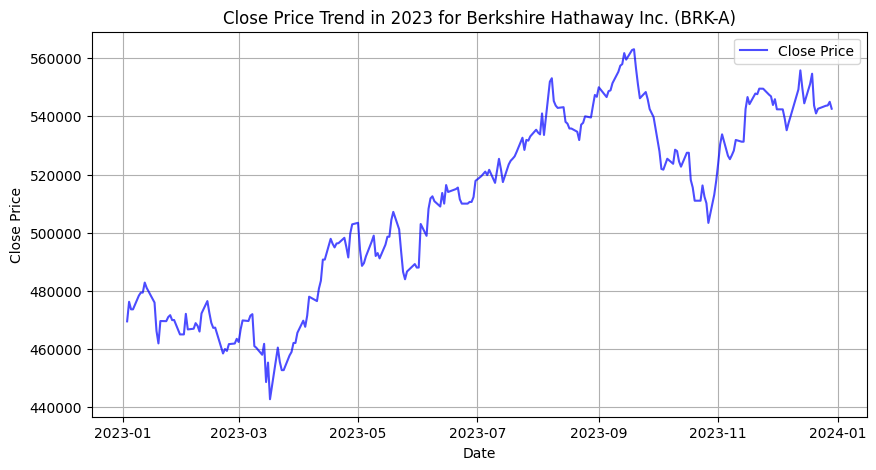

Krispy Kreme, Inc. (DNUT) - Number of rows in 2023: 250


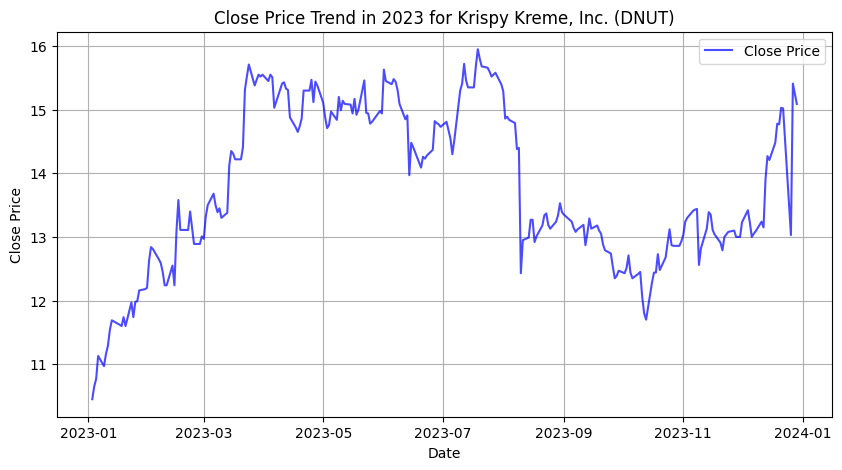

Domino’s Pizza, Inc. (DPZ) - Number of rows in 2023: 250


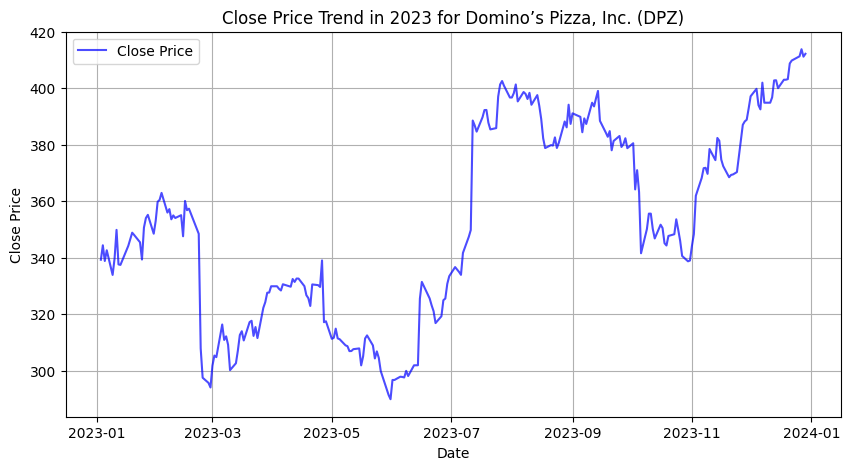

Luckin Coffee Inc. (LKNCY) - Number of rows in 2023: 250


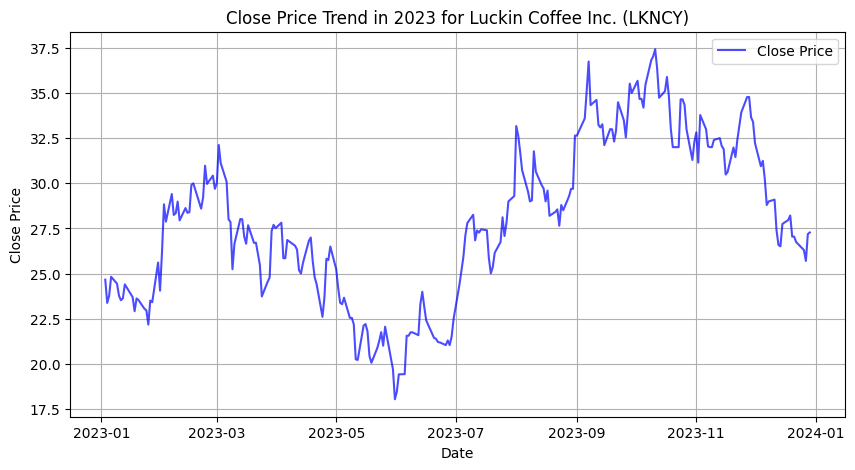

McDonald’s Corporation (MCD) - Number of rows in 2023: 250


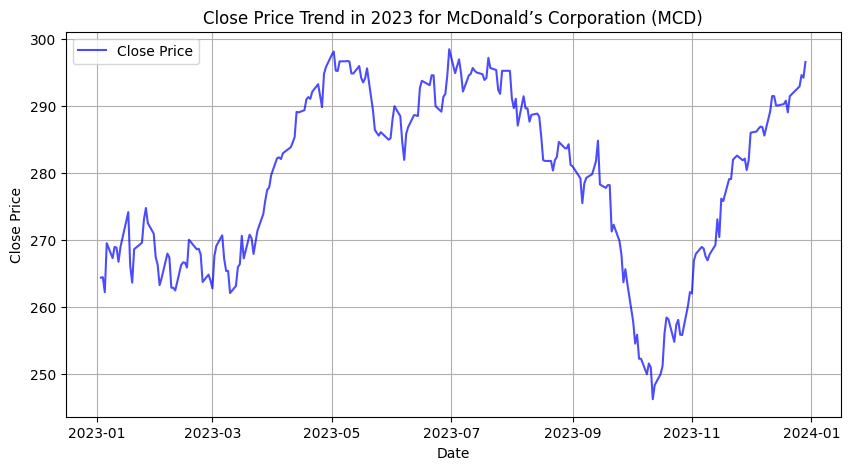

Papa John’s International, Inc. (PZZA) - Number of rows in 2023: 250


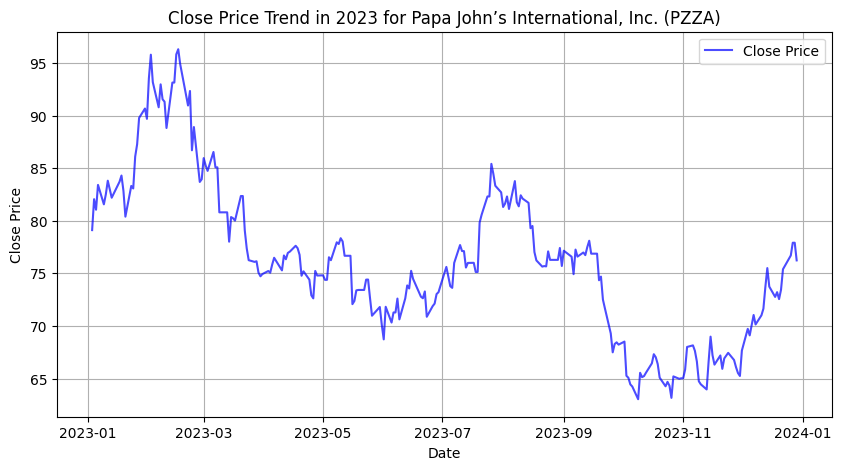

Restaurant Brands International, Inc. (QSR) - Number of rows in 2023: 250


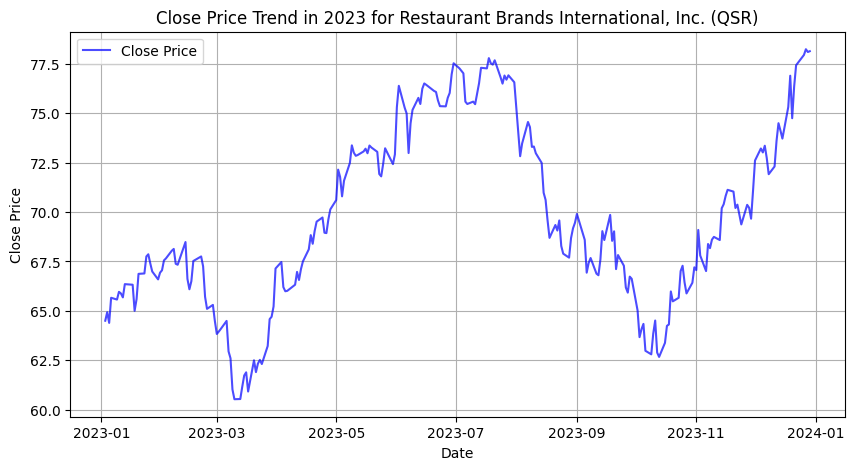

Starbucks Corporation (SBUX) - Number of rows in 2023: 250


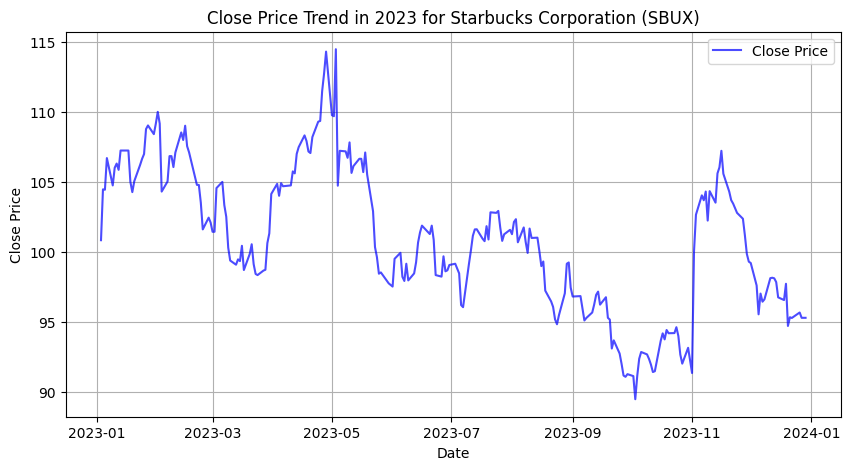

The Wendy’s Corporation (WEN) - Number of rows in 2023: 250


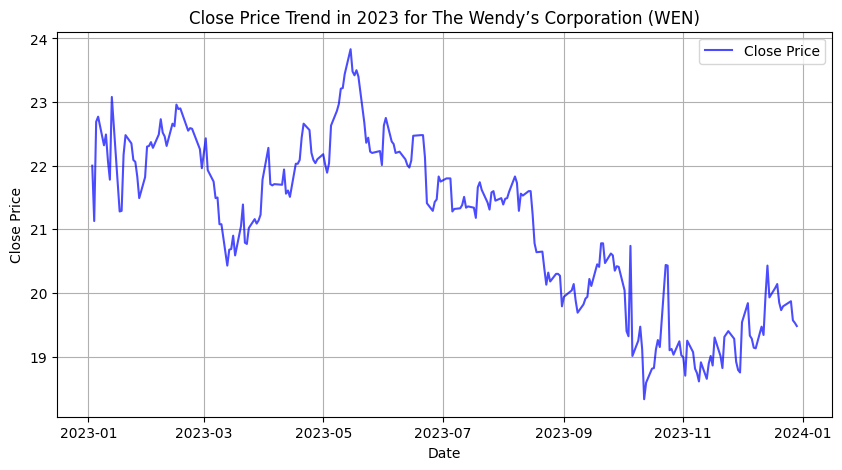

Yum! Brands, Inc. (YUM) - Number of rows in 2023: 250


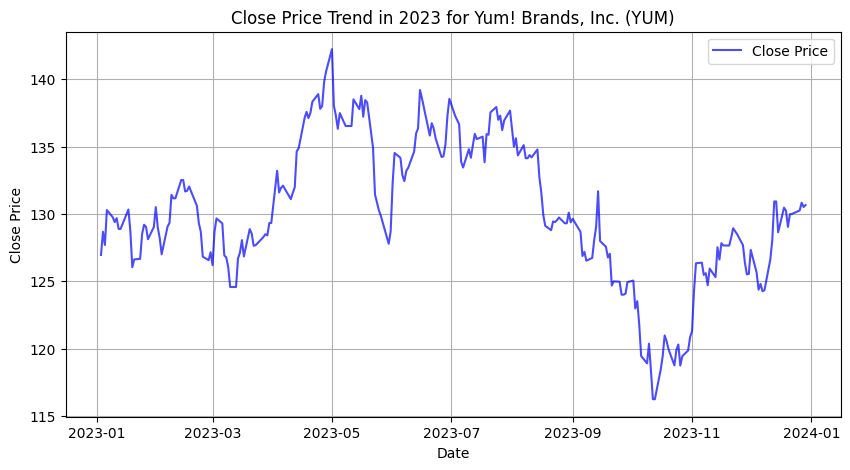

In [12]:
for name, df in datasets.items():  
    try:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        
        # Filter rows for the year 2023
        data_2023 = df[df['Date'].dt.year == 2023]
        print(f"{name} - Number of rows in 2023: {data_2023.shape[0]}")
        
        # Check if data exists for 2023
        if data_2023.empty:
            print(f"No data available for 2023 in {name}.")
            continue
        
        # Plot Close price trend for 2023
        plt.figure(figsize=(10, 5))
        plt.plot(data_2023['Date'], data_2023['Close'], label='Close Price', color='blue', alpha=0.7)
        plt.title(f"Close Price Trend in 2023 for {name}")
        plt.xlabel("Date")
        plt.ylabel("Close Price")
        plt.grid(True)
        plt.legend()
        plt.show()
    except KeyError as e:
        print(f"Error in dataset {name}: Missing column - {e}")
    except Exception as e:
        print(f"Error in processing dataset {name}: {e}")


## **Exercice 3)**

Below you will find the day with the highest Close price for each company for all the period of each dataset.

---


In [13]:
for name, df in datasets.items():  
    try:
        # Here we aim tp Ensure 'Date' and 'Close' columns are valid
        if 'Date' in df.columns and 'Close' in df.columns:
            df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
            
            # Here we drop rows with missing 'Close' or invalid 'Date'
            df = df.dropna(subset=['Close', 'Date']).copy()
            
            # Now we aim to find the row with the highest close price
            highest_close = df.loc[df['Close'].idxmax()]
            
            # Results
            print(f"{name}: The highest Close Price on {highest_close['Date'].strftime('%Y-%m-%d')} - ${highest_close['Close']:.2f}")
        else:
            print(f"{name}: Missing required columns 'Date' or 'Close'.")
    except Exception as e:
        print(f"Error processing dataset {name}: {e}")

Berkshire Hathaway Inc. (BRK-A): The highest Close Price on 2024-09-03 - $715910.00
Krispy Kreme, Inc. (DNUT): The highest Close Price on 2021-07-01 - $21.00
Domino’s Pizza, Inc. (DPZ): The highest Close Price on 2021-12-31 - $564.33
Luckin Coffee Inc. (LKNCY): The highest Close Price on 2020-01-17 - $50.02
McDonald’s Corporation (MCD): The highest Close Price on 2024-01-19 - $300.53
Papa John’s International, Inc. (PZZA): The highest Close Price on 2021-11-04 - $140.01
Restaurant Brands International, Inc. (QSR): The highest Close Price on 2024-03-13 - $82.75
Starbucks Corporation (SBUX): The highest Close Price on 2021-07-26 - $126.06
The Wendy’s Corporation (WEN): The highest Close Price on 1993-09-29 - $32.50
Yum! Brands, Inc. (YUM): The highest Close Price on 2024-04-29 - $143.19


#### **Interpretation:** 

The table above shows the highest **Close Price** for the 10 stocks in each dataset. Most stocks reached their maximum price in recent years (**2020 onwards**), **except for The Wendy’s Corporation (WEN)**.

To analyze this, we adjusted the outlier detection parameters (**MAD threshold = 3**, **Window size = 15**) and reviewed the top 10 highest Close Prices for WEN. These prices were concentrated between **1993 and 2003**, indicating possible changes in the stock pricing structure (**Note:** we delated this steps for simplicity and clear structure).

To confirm, we compared the **Close Price** and **Adjusted Close Price** for all stocks. For all stocks, excpet, WEN both prices aligned, confirming consistency. However, for WEN, the highest **Adjusted Close Price** was from **2023**, highlighting that we think there has been some sort of impact with either:  **stock splits, dividends, or other corporate actions** not reflected correclty in the Close Price.

This is what we belive explains why WEN's Close Price shows an older maximum value. For an accurate analysis, in WEN we recomend using the **Adjusted Close Price** .


In [14]:
# Highest Close and Adjusted Close prices for each dataset
for file_name, df in datasets.items():
    max_close_price = df["Close"].max()
    max_close_date = df.loc[df["Close"] == max_close_price, "Date"].iloc[0]

    max_adj_close_price = df["Adj Close"].max()
    max_adj_close_date = df.loc[df["Adj Close"] == max_adj_close_price, "Date"].iloc[0]

    print(f"=== {file_name} ===")
    print(f"The Highest Close Price is: ${max_close_price:.2f} on {max_close_date}")
    print(f"The Highest Adjusted Close Price is: ${max_adj_close_price:.2f} on {max_adj_close_date}")
    print("-" * 50)



=== Berkshire Hathaway Inc. (BRK-A) ===
The Highest Close Price is: $715910.00 on 2024-09-03 00:00:00
The Highest Adjusted Close Price is: $715910.00 on 2024-09-03 00:00:00
--------------------------------------------------
=== Krispy Kreme, Inc. (DNUT) ===
The Highest Close Price is: $21.00 on 2021-07-01 00:00:00
The Highest Adjusted Close Price is: $18.70 on 2021-07-09 00:00:00
--------------------------------------------------
=== Domino’s Pizza, Inc. (DPZ) ===
The Highest Close Price is: $564.33 on 2021-12-31 00:00:00
The Highest Adjusted Close Price is: $544.40 on 2021-12-31 00:00:00
--------------------------------------------------
=== Luckin Coffee Inc. (LKNCY) ===
The Highest Close Price is: $50.02 on 2020-01-17 00:00:00
The Highest Adjusted Close Price is: $50.02 on 2020-01-17 00:00:00
--------------------------------------------------
=== McDonald’s Corporation (MCD) ===
The Highest Close Price is: $300.53 on 2024-01-19 00:00:00
The Highest Adjusted Close Price is: $296.53 o

## **Exercice 4)**

Below is a graph displaying the monthly average Close price for three selected companies: Krispy Kreme, Inc. (DNUT), Domino's Pizza, Inc. (DPZ), and Yum! Brands, Inc. (YUM).

We selected these companies for comparison because they share **similar timeframes** with overlapping historical data, enabling meaningful analysis. Additionally, their **comparable price ranges** minimize significant differences in stock values, eliminating the need for normalization and simplifying the analysis process.

**Note**: we analyzed the data from 2004-2024 becasue it is when we have data for the tree companies.

---


C:\Users\enric\AppData\Local\Temp\ipykernel_14280\868375736.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df['Date'].dt.to_period('M')
C:\Users\enric\AppData\Local\Temp\ipykernel_14280\868375736.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df['Date'].dt.to_period('M')


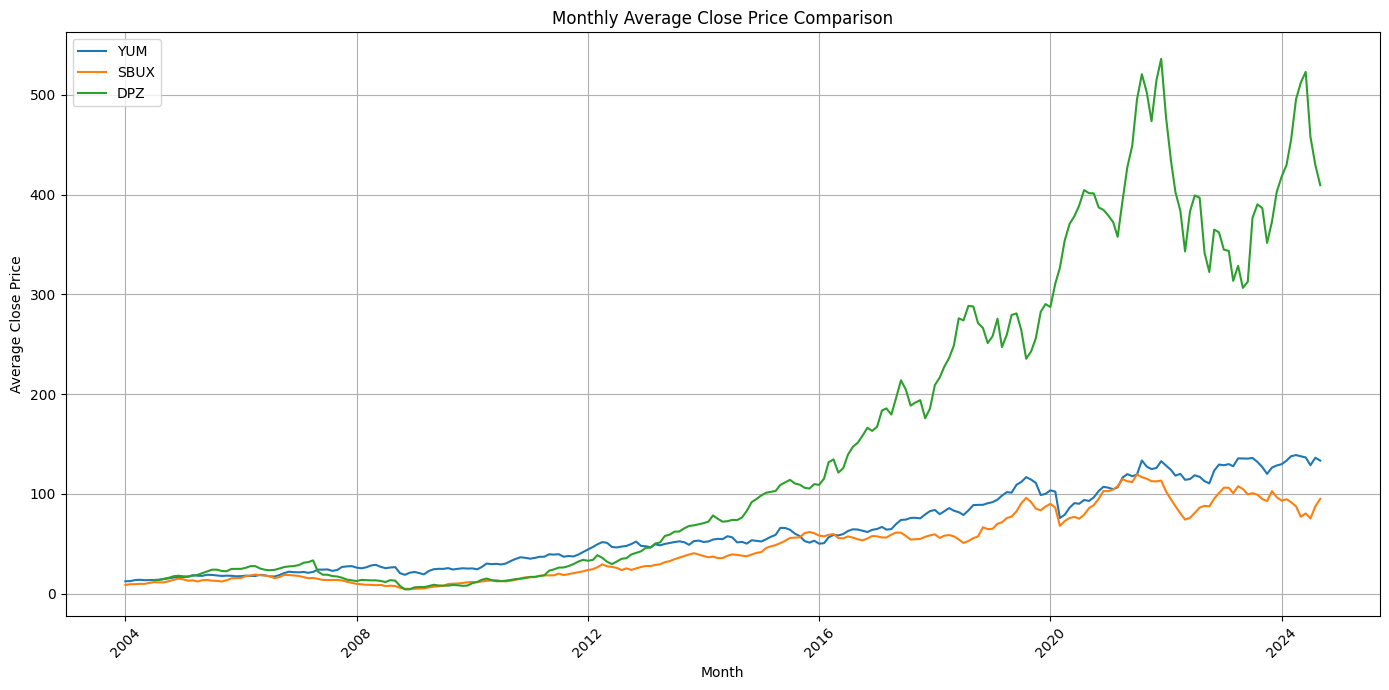

In [15]:
selected_companies = [
    ("YUM", datasets["Yum! Brands, Inc. (YUM)"]),
    ("SBUX", datasets["Starbucks Corporation (SBUX)"]),
    ("DPZ", datasets["Domino’s Pizza, Inc. (DPZ)"])
]

# Data starting in 2004
start_date = "2004-01-01"

# Initialize the plot for comparison
plt.figure(figsize=(14, 7))

for name, df in selected_companies:
    # Ensure 'Date' is in datetime format
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Filter data starting from 2004
    df = df[df['Date'] >= start_date]
    
    # Group data by month and compute the average Close price
    df['Month'] = df['Date'].dt.to_period('M')
    monthly_avg = df.groupby('Month')['Close'].mean()
    
    # Plot the monthly average Close prices
    plt.plot(monthly_avg.index.to_timestamp(), monthly_avg, label=name)

# Add titles, labels, and legend
plt.title("Monthly Average Close Price Comparison")
plt.xlabel("Month")
plt.ylabel("Average Close Price")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## **Exercice 5A)**

Below is the **yearly average Close Price** for each company over the entire timeframe of their respective datasets. 

---

In [16]:
yearly_averages = {}

# Calculate the yearly average Close price
for name, df in datasets.items():
    try:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

        # Drop rows with invalid dates or missing Close prices
        df = df.dropna(subset=['Date', 'Close']).copy()

        # Extract year and compute yearly average Close price
        df['Year'] = df['Date'].dt.year
        yearly_avg = df.groupby('Year')['Close'].mean().round(2)

        # Store the result
        yearly_averages[name] = yearly_avg

        # Print yearly averages for each company
        print(f"Yearly Averages for {name}:\n{yearly_avg}\n")
    except Exception as e:
        print(f"Error processing dataset {name}: {e}")
        



Yearly Averages for Berkshire Hathaway Inc. (BRK-A):
Year
1980       352.59
1981       493.31
1982       541.18
1983      1029.55
1984      1283.08
1985      1981.30
1986      2776.77
1987      3443.76
1988      4048.34
1989      6800.48
1990      6872.51
1991      8227.21
1992      9344.26
1993     15013.19
1994     17694.55
1995     25516.55
1996     32703.38
1997     41964.67
1998     65213.34
1999     66612.07
2000     57284.70
2001     68775.68
2002     72407.15
2003     73396.42
2004     88324.76
2005     85995.91
2006     94460.67
2007    116500.77
2008    122228.27
2009     93771.09
2010    117702.16
2011    116451.91
2012    125154.52
2013    165349.22
2014    195635.89
2015    210604.40
2016    216162.86
2017    262749.62
2018    305938.88
2019    312335.61
2020    307663.62
2021    410850.13
2022    458205.26
2023    509415.48
2024    622715.57
Name: Close, dtype: float64

Yearly Averages for Krispy Kreme, Inc. (DNUT):
Year
2021    15.39
2022    13.92
2023    13.78
2024    1

## **Exercice 5B)**

---

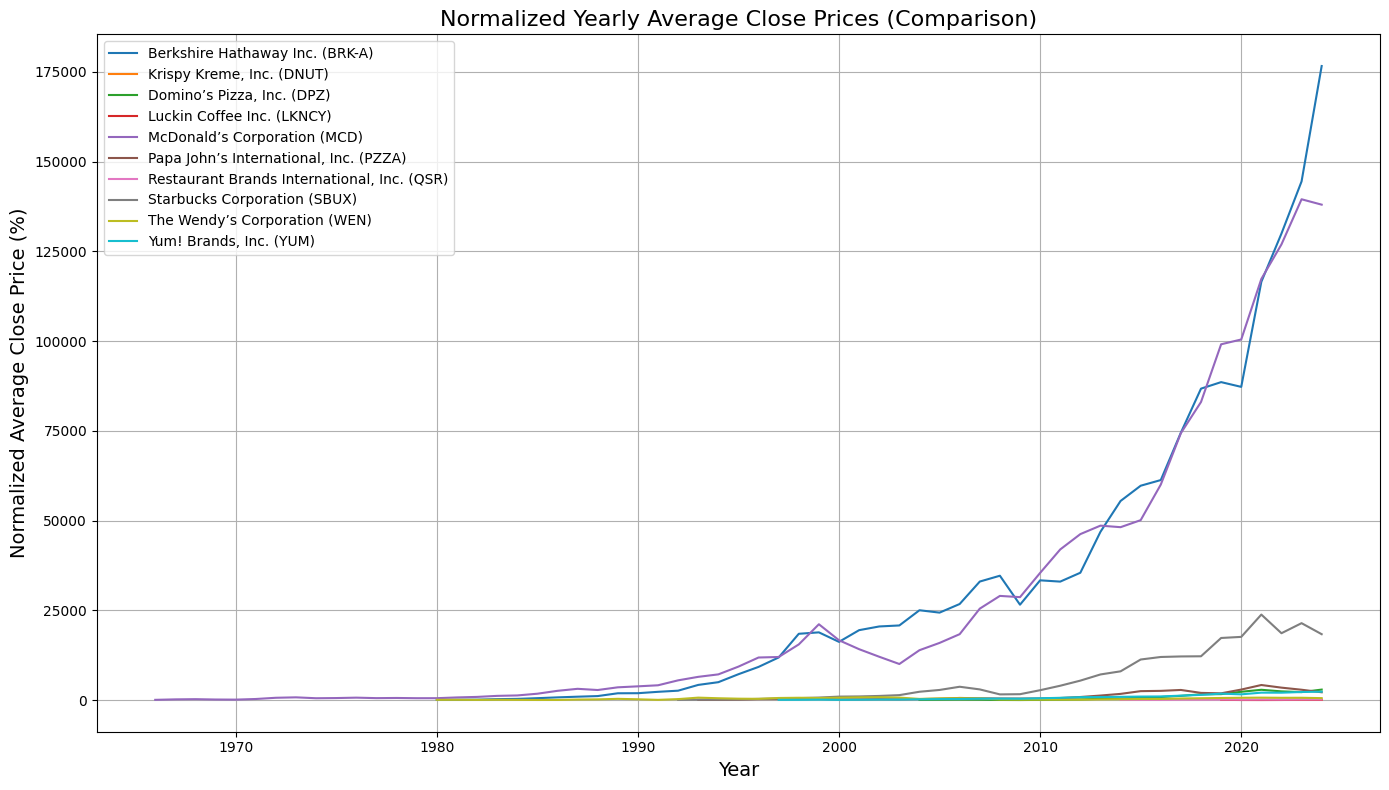

In [17]:
yearly_averages_plot = {}

# Process each dataset to compute yearly averages
for name, df in datasets.items():
    if "Close" in df.columns and "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        
        # Drop rows with invalid dates or missing Close prices
        df = df.dropna(subset=["Date", "Close"]).copy()
        
        # Extract the year from the Date column
        df["Year"] = df["Date"].dt.year
        
        # Group by year and calculate the average Close price
        yearly_avg = df.groupby("Year")["Close"].mean().round(2)
        
        # Store the result
        yearly_averages_plot[name] = yearly_avg

# Plot normalized yearly averages for all companies
plt.figure(figsize=(14, 8))

for name, yearly_avg in yearly_averages_plot.items():
    # Normalize yearly averages relative to the first year's average
    normalized_avg = (yearly_avg / yearly_avg.iloc[0]) * 100
    plt.plot(normalized_avg.index, normalized_avg.values, label=name)

# Add titles, labels, and legend
plt.title("Normalized Yearly Average Close Prices (Comparison)", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Normalized Average Close Price (%)", fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True)
plt.tight_layout()

# Display the plot
plt.show()




#### **Interpretation**

The decision to normalize the yearly average Close prices comes from the significant differences in the absolute values of stock prices across the datasets. Companies like **Berkshire Hathaway Inc. (BRK-A)** have exceptionally high stock prices compared to others, such as **Krispy Kreme, Inc. (DNUT)** or **Yum! Brands, Inc. (YUM)**. This disparity made the comparison of trends in absolute terms ineffective, as the graph would primarily reflect the fluctuations of higher-value stocks, rendering data from lower-value stocks less discernible.

By normalizing the prices, we scaled the data relative to each company’s first recorded yearly average, allowing us to focus on the **comparison of trends** rather than absolute values and ensuring equal representation across all companies. This approach enables effective trend comparison and ensures all companies contribute equally to the analysis.




## **Exercice 6)**


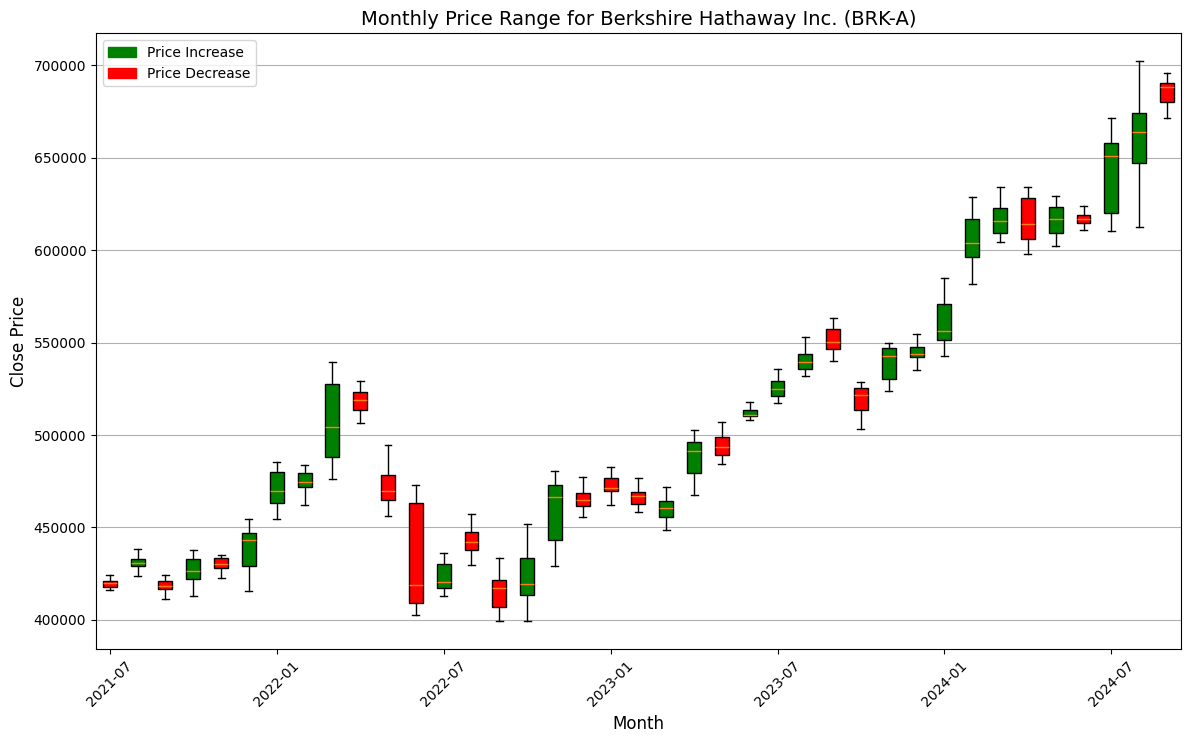

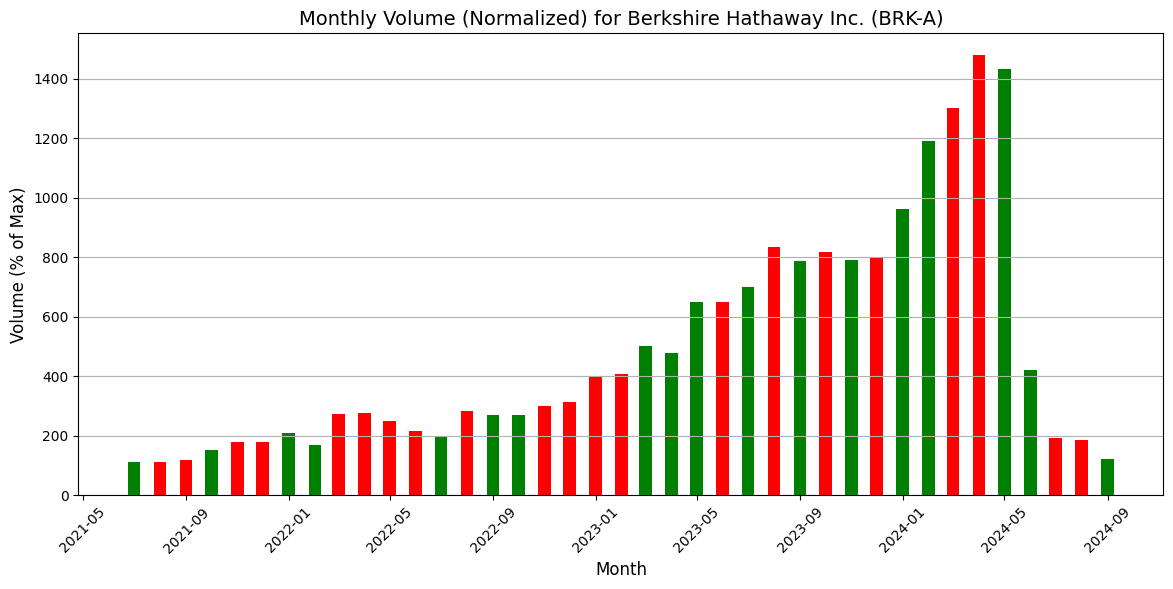

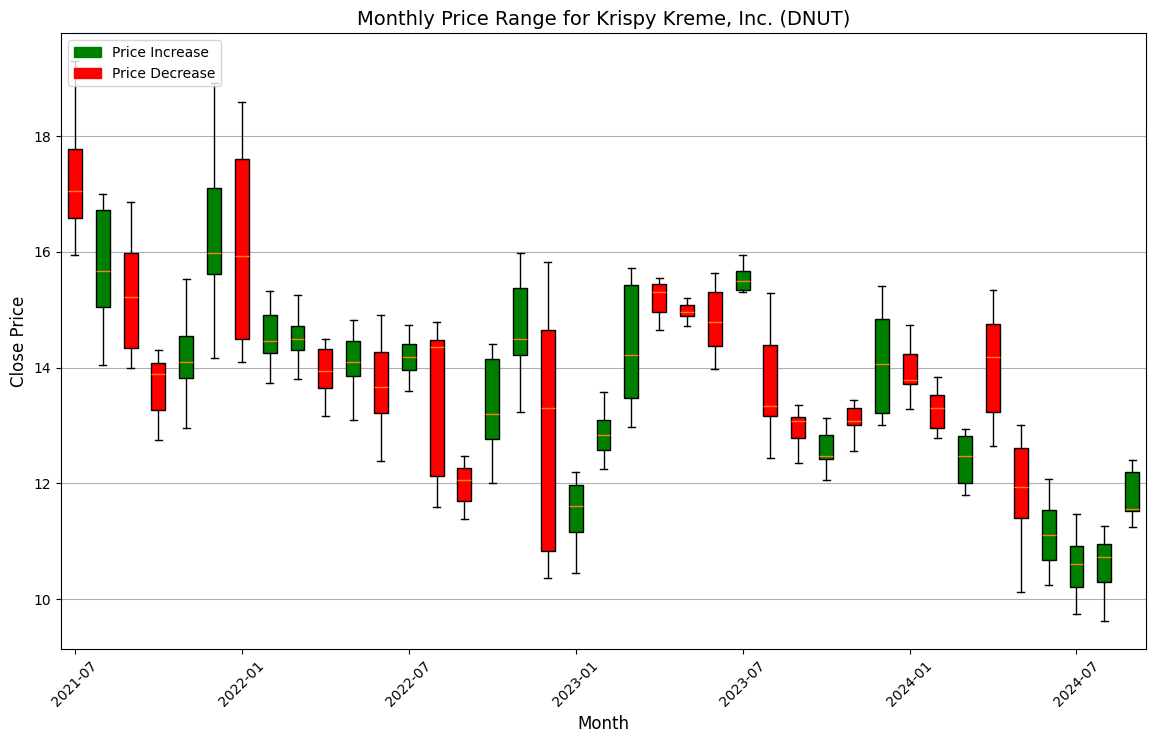

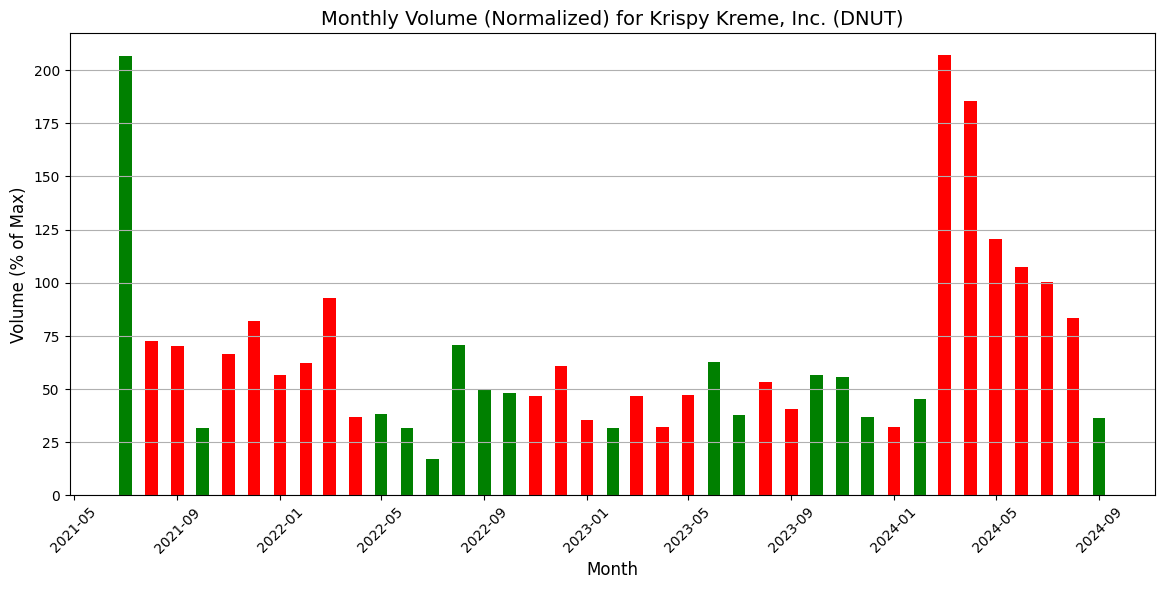

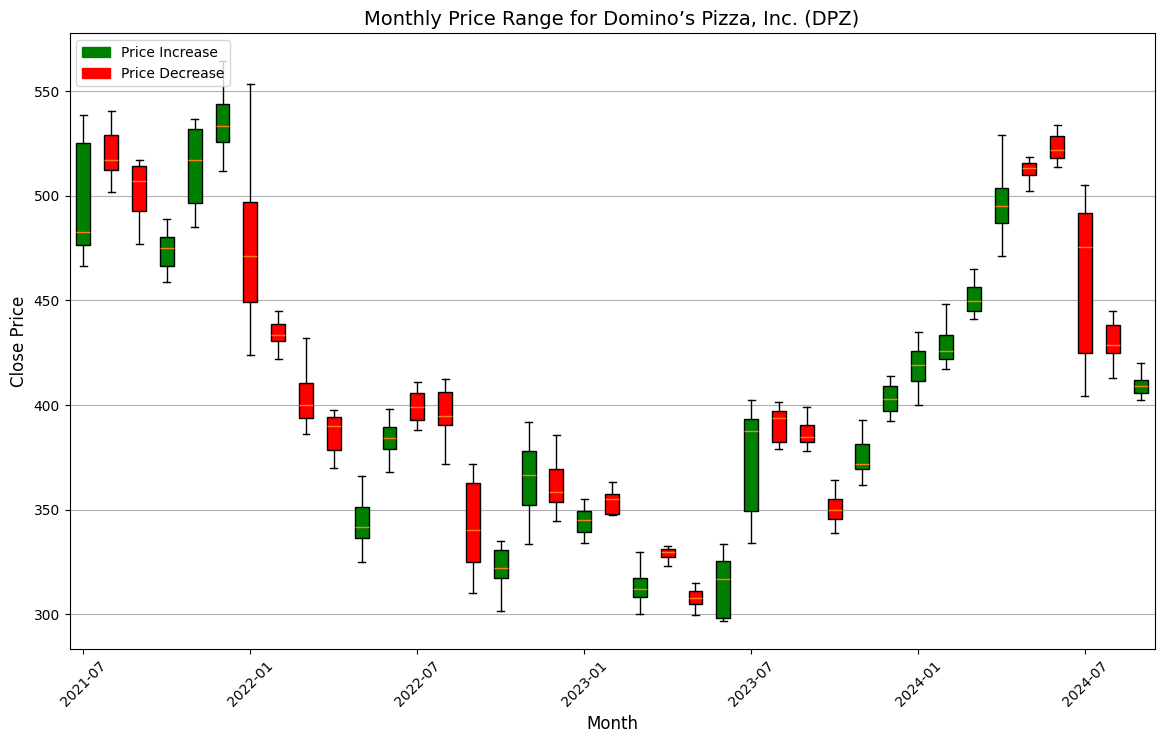

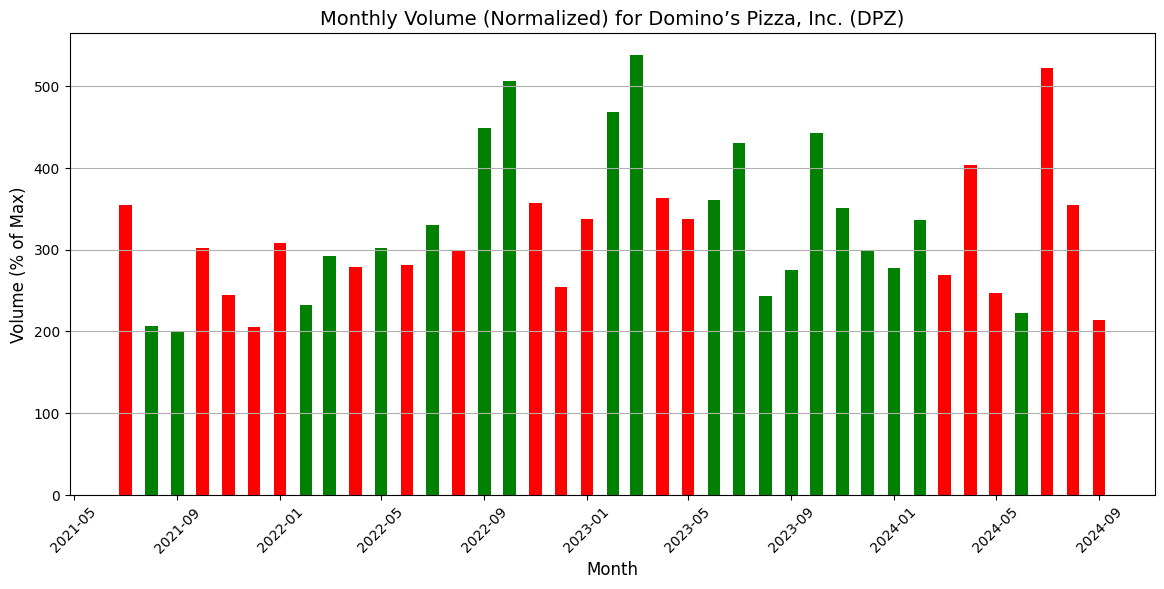

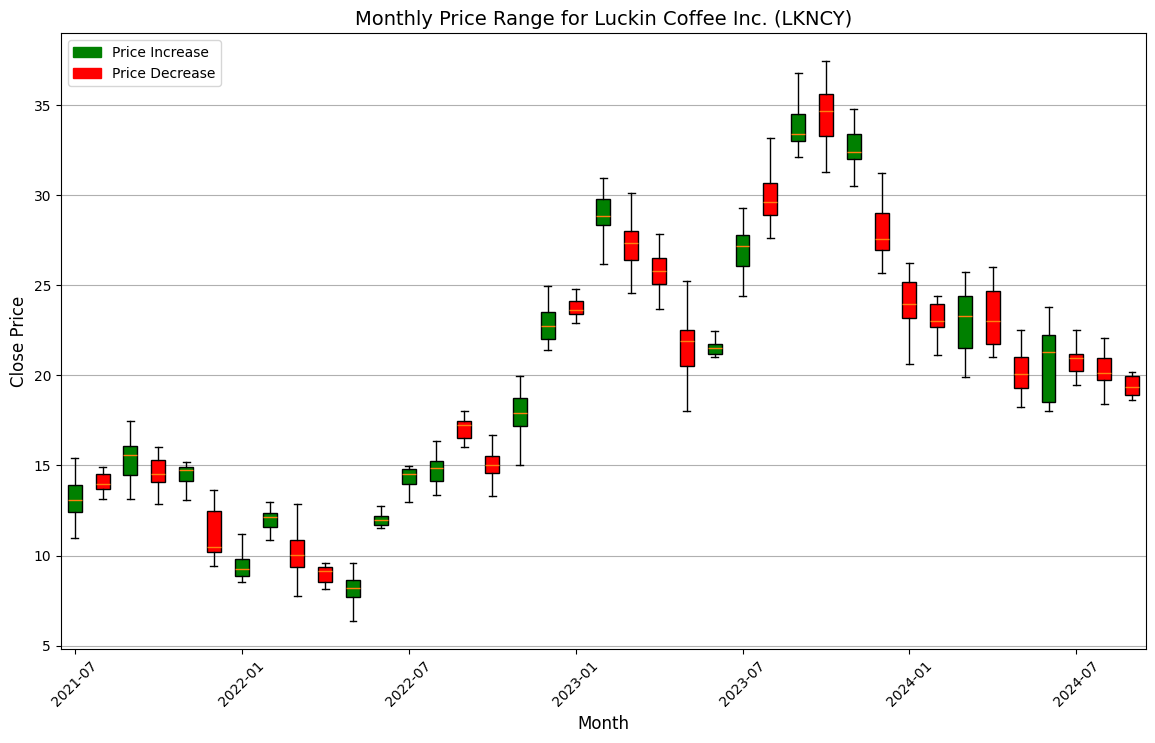

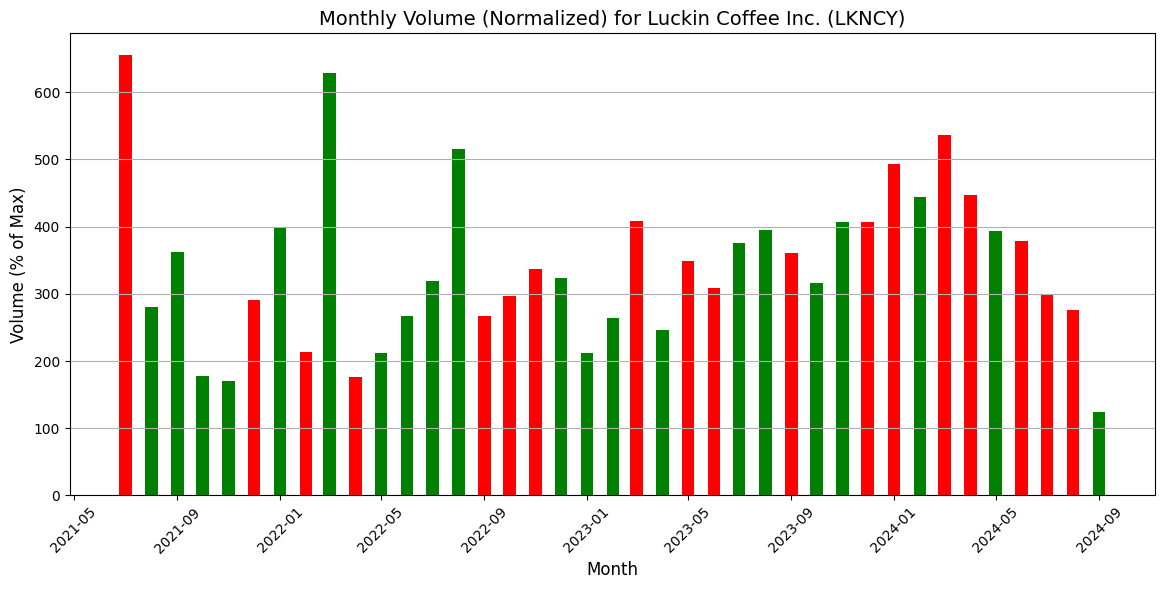

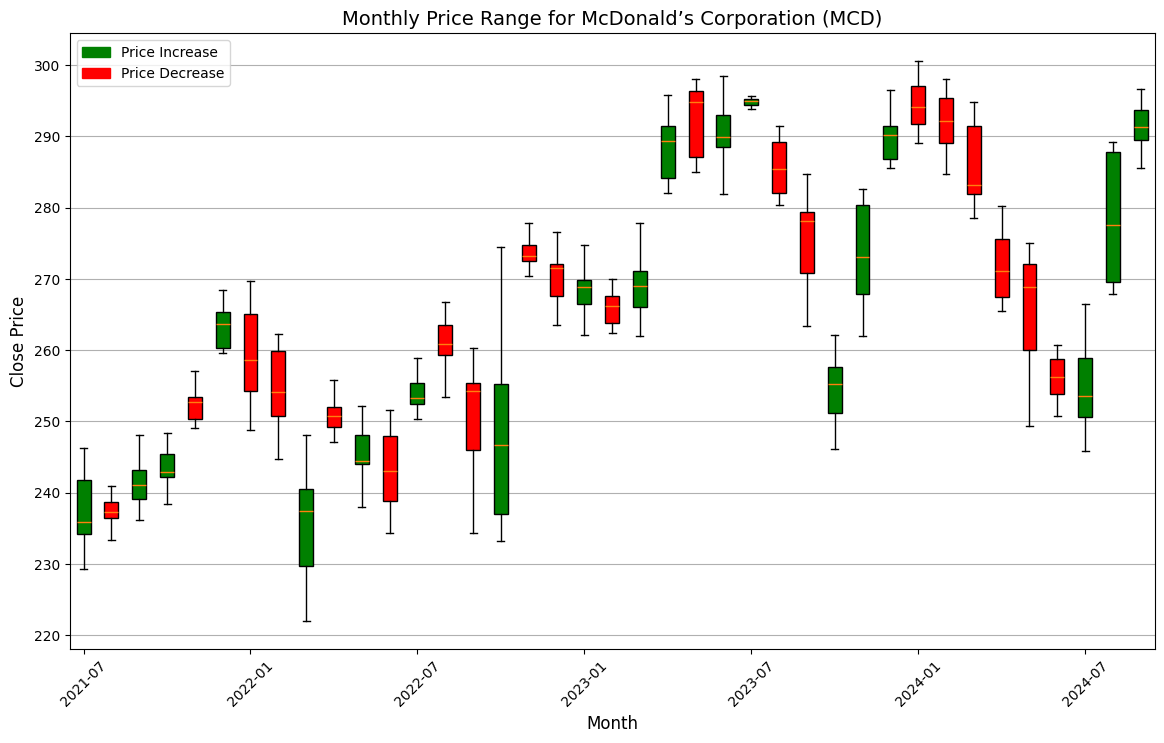

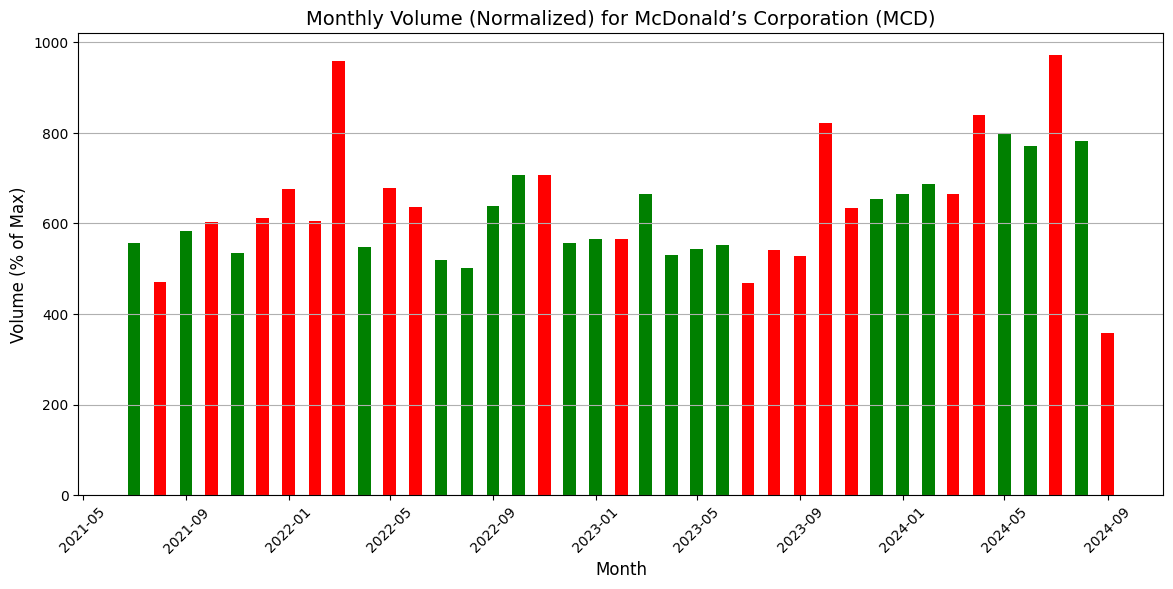

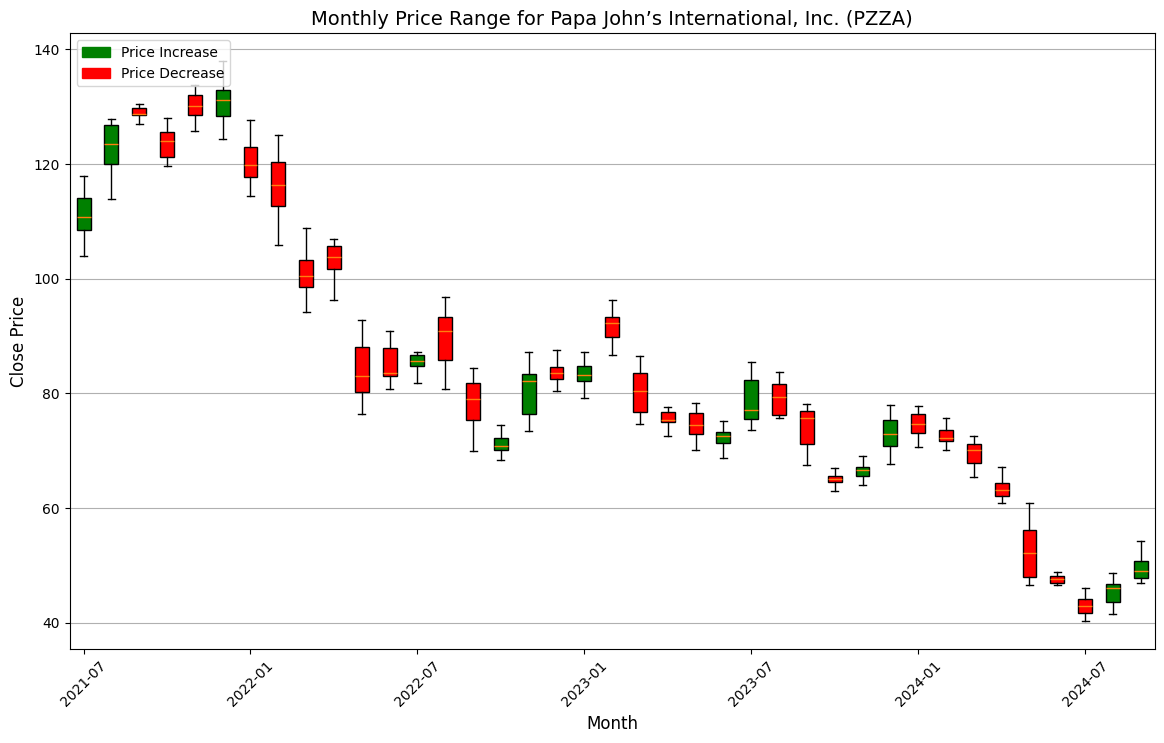

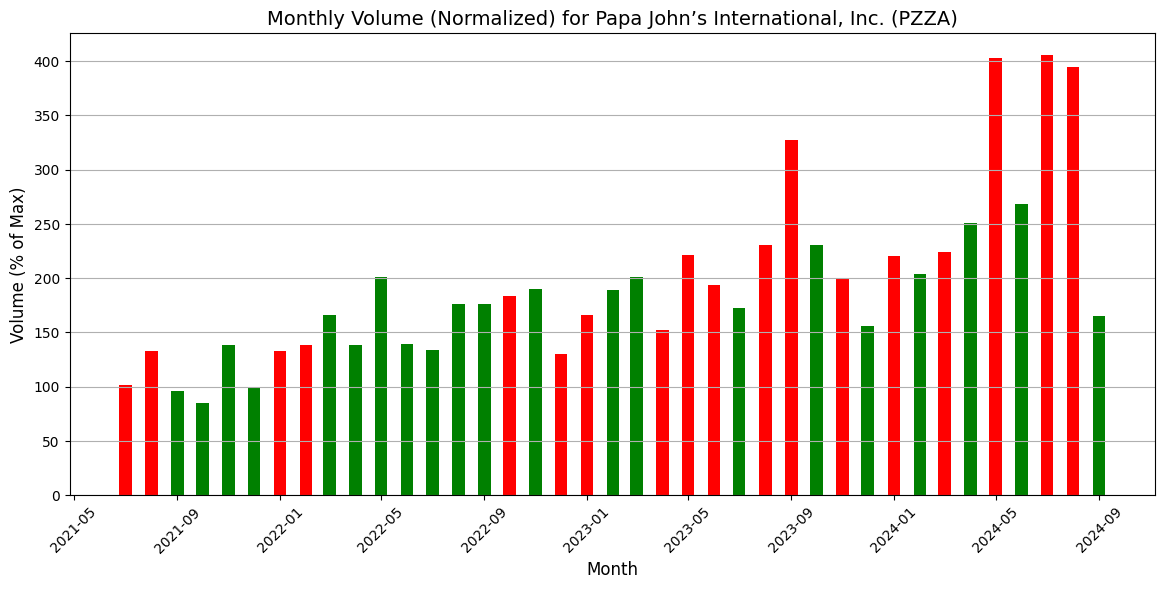

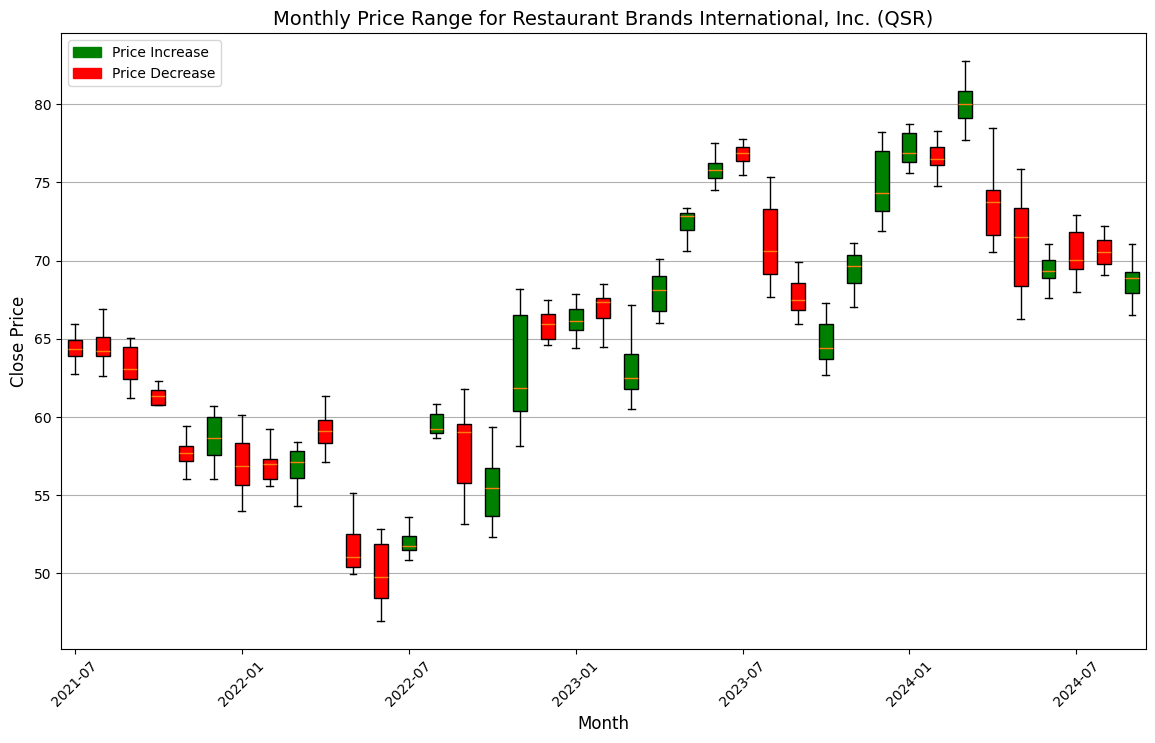

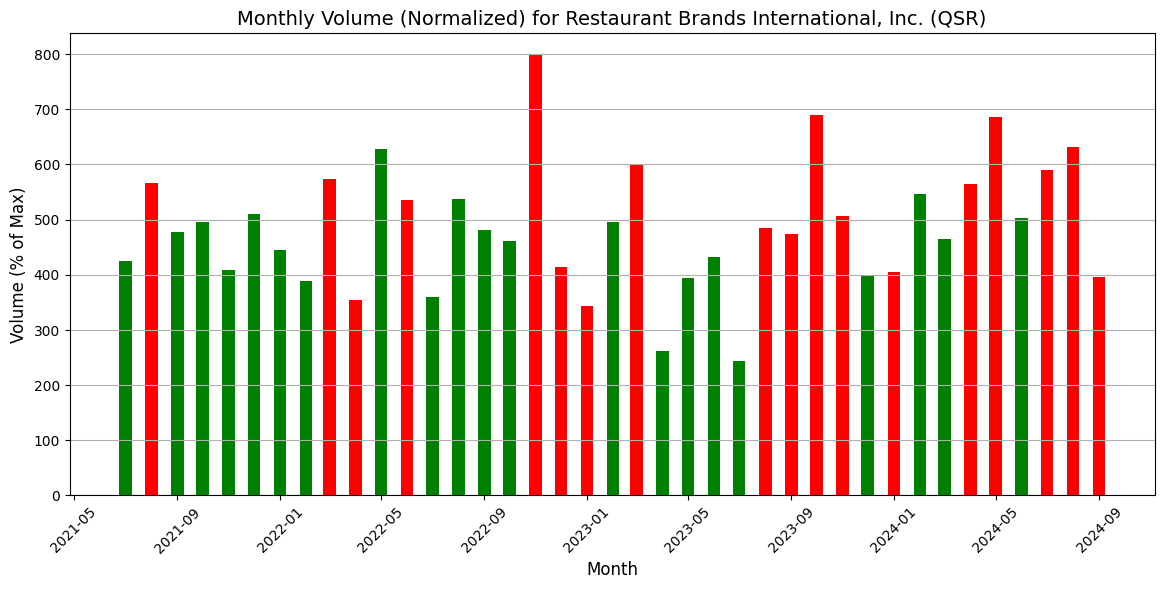

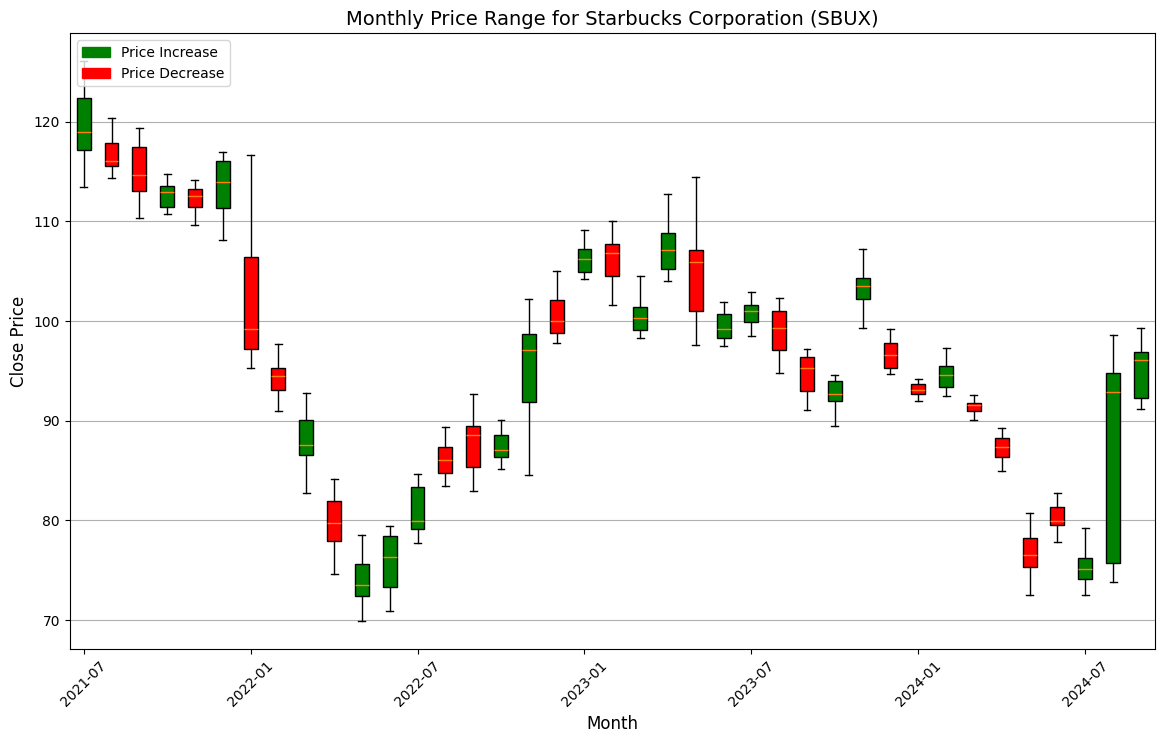

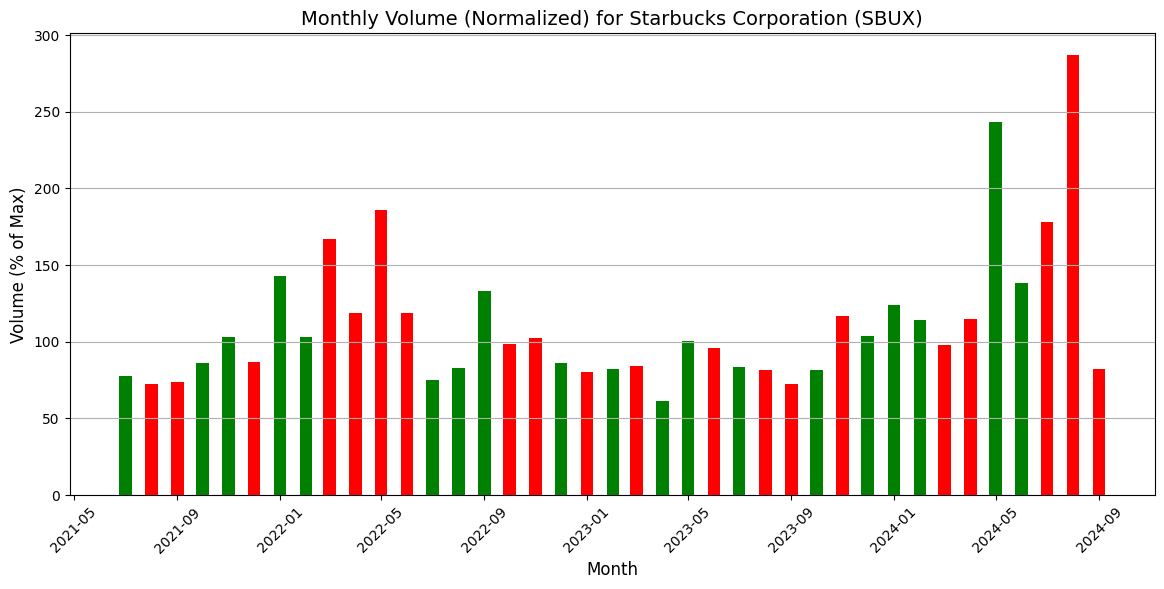

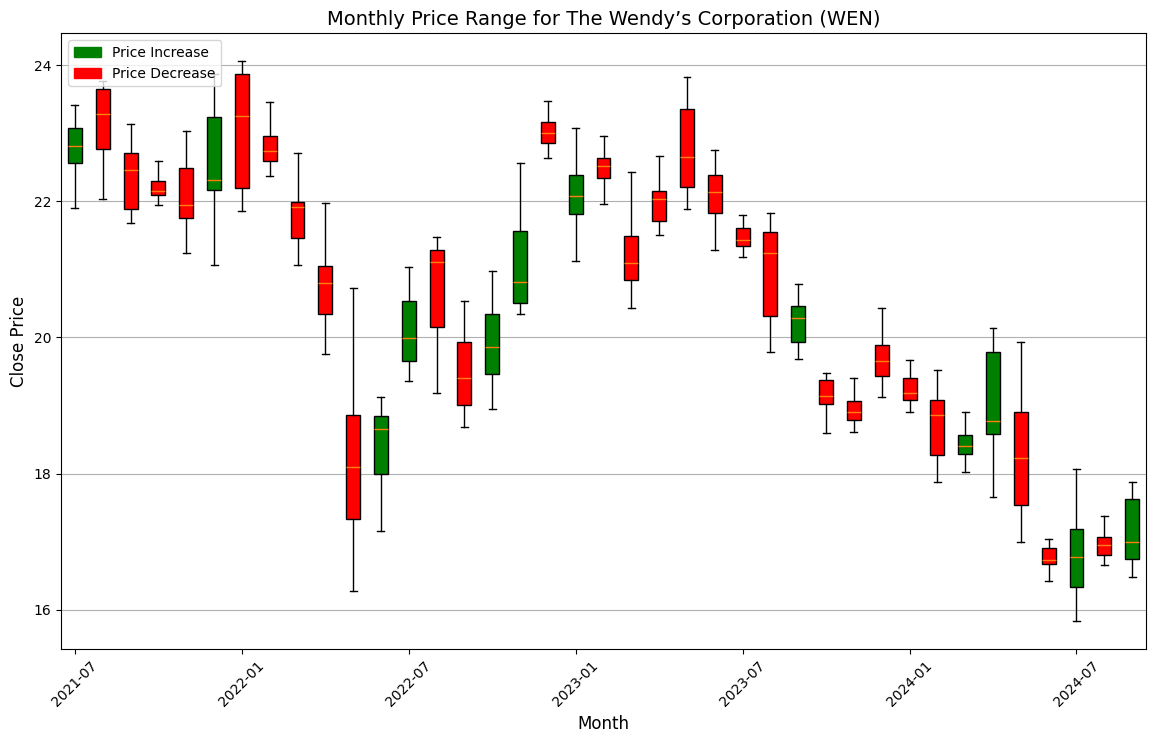

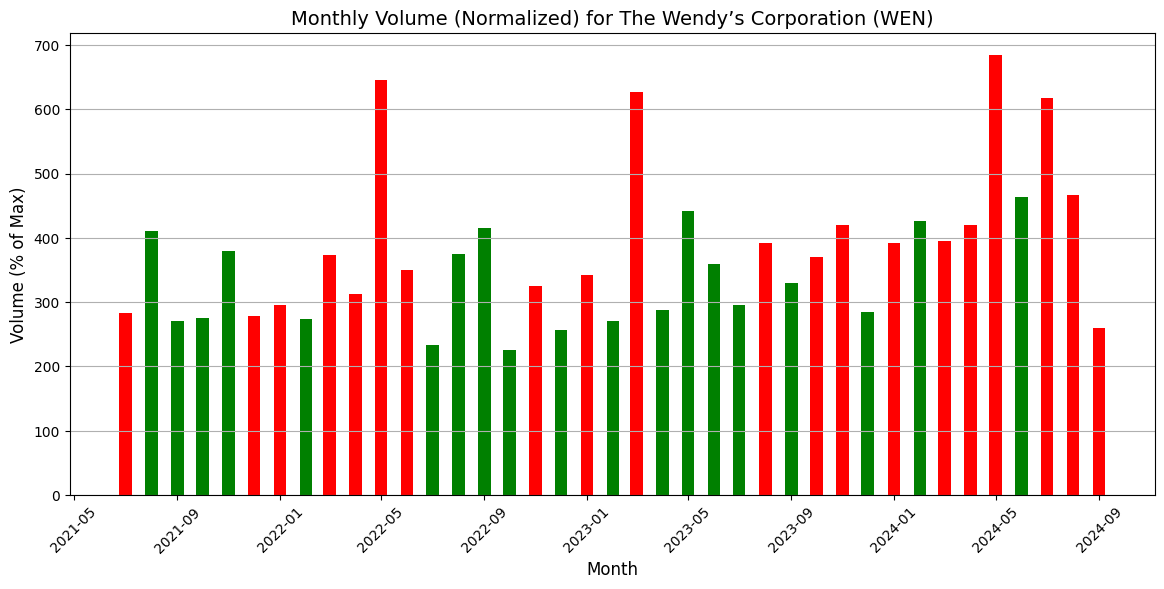

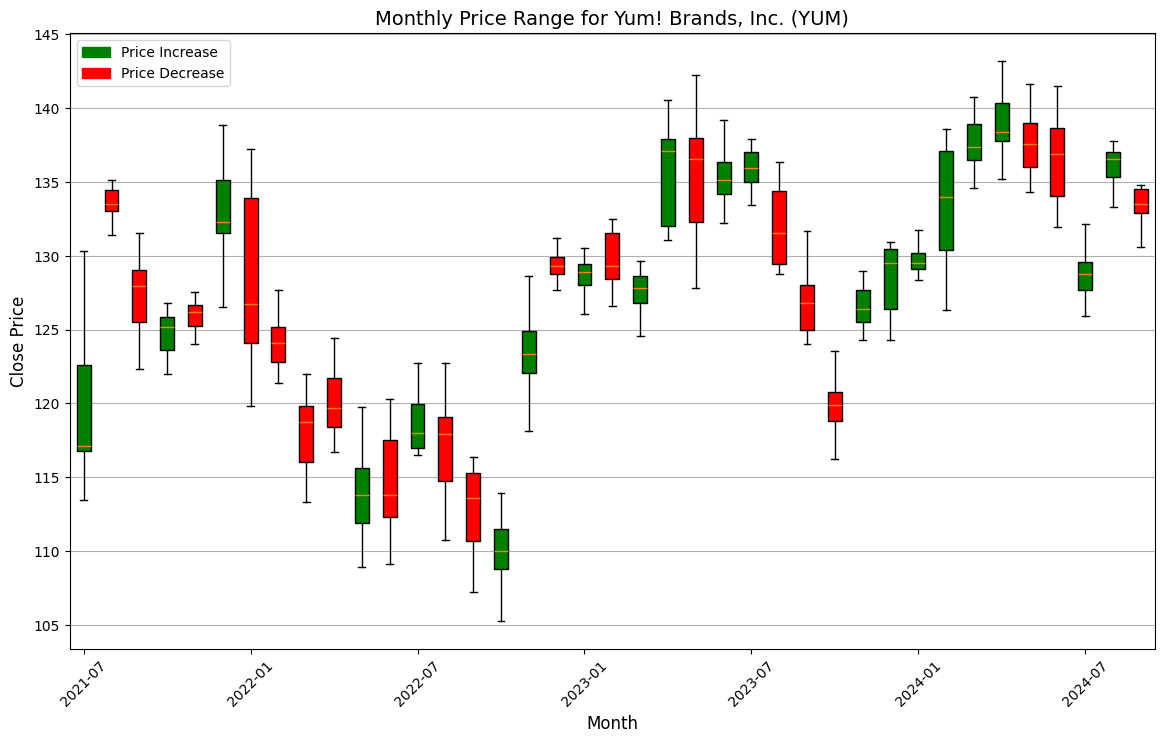

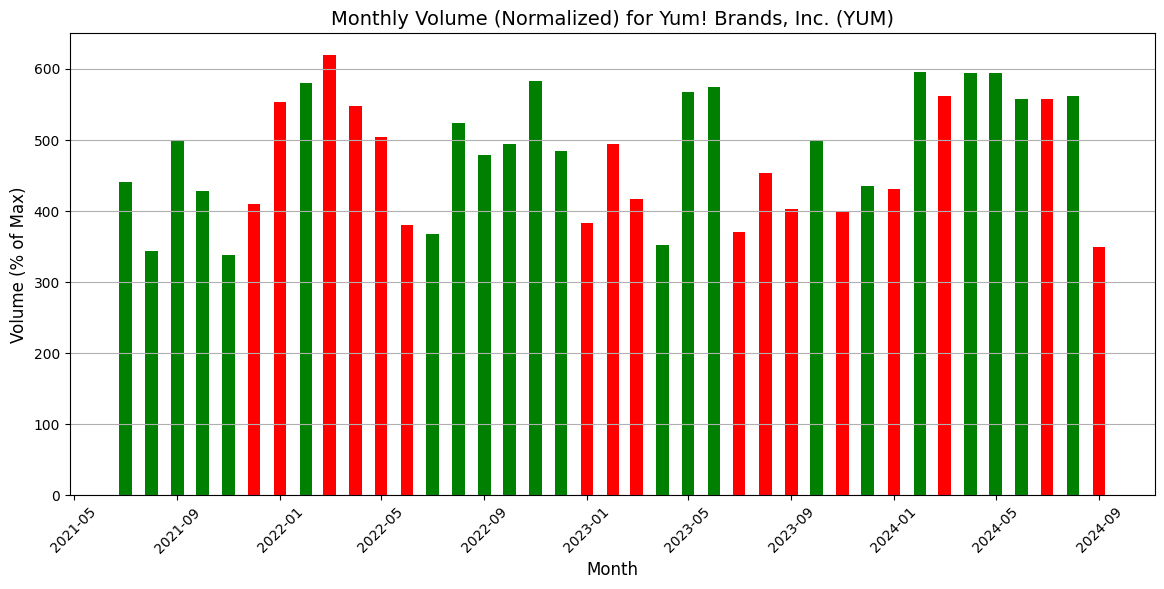

In [18]:
filtered_datasets = {}

# We filtered all datasets to match the time range of the shortest 
krispy_kreme_df = datasets.get("Krispy Kreme, Inc. (DNUT)")
if krispy_kreme_df is not None and "Close" in krispy_kreme_df.columns and "Date" in krispy_kreme_df.columns:
    krispy_kreme_df_copy = krispy_kreme_df.copy()
    krispy_kreme_df_copy["Date"] = pd.to_datetime(krispy_kreme_df_copy["Date"], errors="coerce")
    krispy_kreme_df_copy = krispy_kreme_df_copy.dropna(subset=["Date", "Close"])
    min_date = krispy_kreme_df_copy["Date"].min()
    max_date = krispy_kreme_df_copy["Date"].max()
else:
    raise ValueError("Krispy Kreme dataset is missing 'Date' or 'Close' columns.")

# Here we filtered each dataset without altering the original 'datasets' dictionary.
for name, df in datasets.items():
    if "Date" in df.columns and "Close" in df.columns:
        df_filtered = df.copy()
        df_filtered["Date"] = pd.to_datetime(df_filtered["Date"], errors="coerce")
        df_filtered = df_filtered.dropna(subset=["Date", "Close"])
        df_filtered = df_filtered[(df_filtered["Date"] >= min_date) & (df_filtered["Date"] <= max_date)]
        df_filtered["YearMonth"] = df_filtered["Date"].dt.to_period("M")
        filtered_datasets[name] = df_filtered
    else:
        print(f"Dataset \"{name}\" is missing 'Date' or 'Close' columns and will be skipped.")

# Here we plotted using the filtered_datasets 
for name, df in filtered_datasets.items():
    if "Close" in df.columns and "YearMonth" in df.columns:
        # Box plot preparation
        monthly_groups = df.groupby("YearMonth")["Close"]
        monthly_changes = []
        for year_month, group in monthly_groups:
            if len(group) > 1:
                first_price = group.iloc[0]
                last_price = group.iloc[-1]
                monthly_changes.append(last_price > first_price)

        plt.figure(figsize=(14, 8))
        monthly_groups_list = [group for g_name, group in monthly_groups if len(group) > 1]
        box = plt.boxplot(
            monthly_groups_list,
            patch_artist=True,
            showfliers=False,
        )

        # Color the boxes based on monthly price change
        for patch, price_increase in zip(box["boxes"], monthly_changes):
            patch.set_facecolor("green" if price_increase else "red")

        # X-axis labels (showing every 6th month)
        months = [str(g_name) for i, (g_name, group) in enumerate(monthly_groups) if i % 6 == 0]
        plt.xticks(
            ticks=range(1, len(monthly_groups_list) + 1, 6),
            labels=months,
            rotation=45,
        )

        plt.title(f"Monthly Price Range for {name}", fontsize=14)
        plt.xlabel("Month", fontsize=12)
        plt.ylabel("Close Price", fontsize=12)
        plt.grid(axis="y")

        green_patch = mpatches.Patch(color="green", label="Price Increase")
        red_patch = mpatches.Patch(color="red", label="Price Decrease")
        plt.legend(handles=[green_patch, red_patch], loc="upper left")
        plt.show()

        # Plot normalized volume
        plt.figure(figsize=(14, 6))
        df["Normalized Volume"] = df["Volume"] / df["Volume"].max() * 100
        df["Volume Color"] = ["green" if c >= o else "red" for o, c in zip(df["Open"], df["Close"])]

        grouped_volumes = df.groupby("YearMonth")[["Normalized Volume", "Volume Color"]]
        for year_month, group in grouped_volumes:
            group_dt = year_month.to_timestamp()
            color = "green" if group["Volume Color"].iloc[0] == "green" else "red"
            plt.bar(group_dt, group["Normalized Volume"].sum(), color=color, width=15)

        plt.title(f"Monthly Volume (Normalized) for {name}", fontsize=14)
        plt.xlabel("Month", fontsize=12)
        plt.ylabel("Volume (% of Max)", fontsize=12)
        plt.xticks(rotation=45)
        plt.grid(axis="y")
        plt.show()

    else:
        print(f"Dataset \"{name}\" is missing necessary columns for plotting.")



#### **Interpretation:**

The graphs above display the **monthly price range** and **trading activity** (Volume (*Additional Not required in the exercice*)), filtered to match the time range of Krispy Kreme, ensuring consistency across all datasets.

#### **Methodology:**
We followed standard financial charting practices:
- **Box Plots for Monthly Price Ranges**: summarize the variability of monthly **Close prices**, showing medians, quartiles, and outliers.
    - **Green Candles**: indicate months with a price increase (last Close > first Close).
    - **Red Candles**: indicate months with a price decrease (last Close < first Close).
- **Normalized Volume Charts**: we normalized the volume as a percentage of each company’s maximum monthly volume, making trading activity comparable across companies.

#### **Justification:**
- **Box Plots** provide us a standard way to represent price variability and trends over time in the financial industry.
- **Normalized Volume** ensures fair comparisons, even when companies have different trading volumes.

#### **Conlusions:**
We chosed this type of plot as we belive that it is the standard in finance, allowing us clear analysis of price trends and trading activity while maintaining consistency across datasets.

## **Exercice 7**:

---

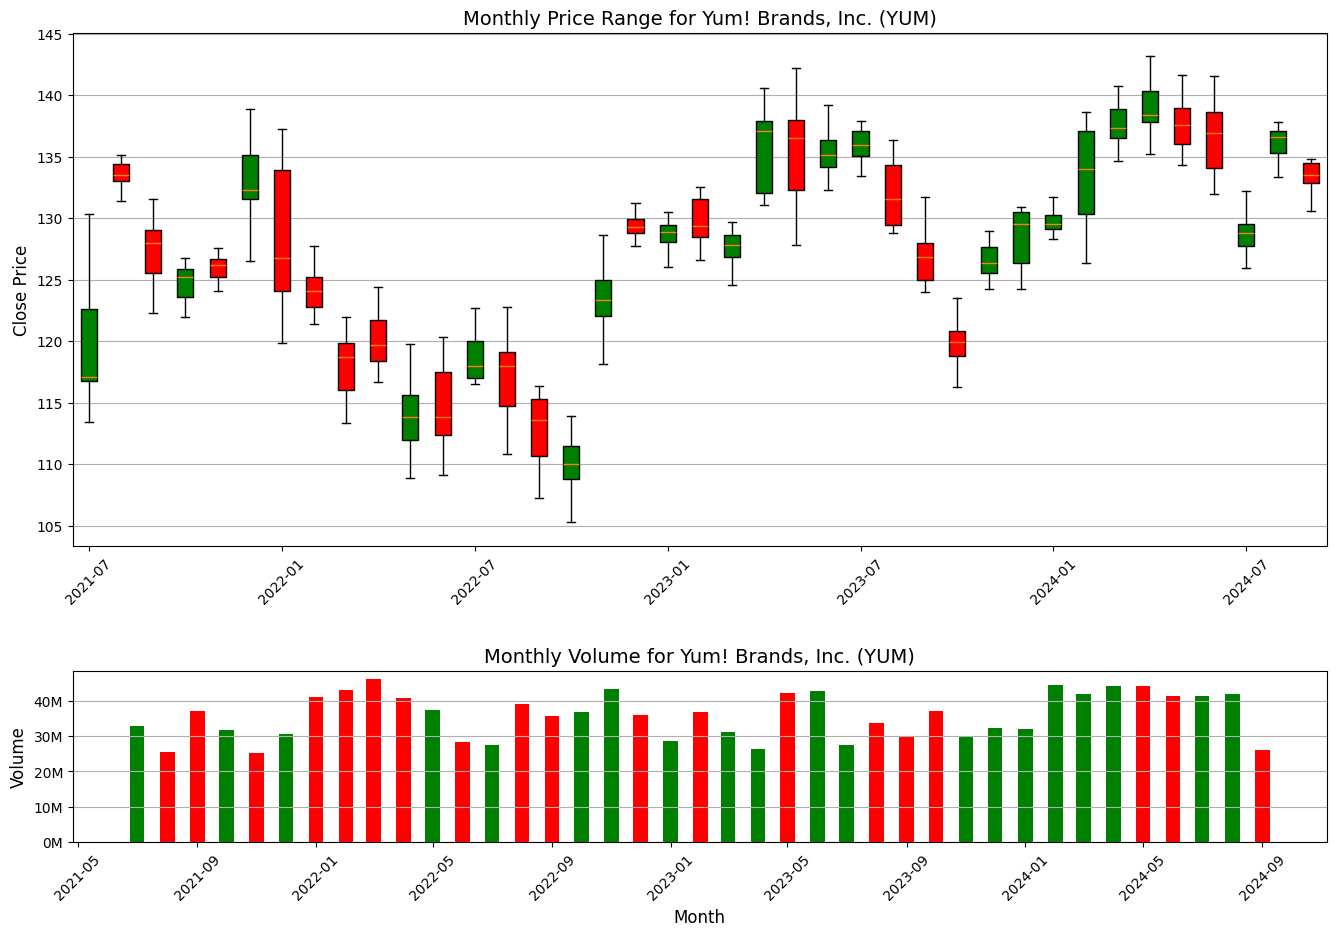

In [19]:
yum_df = datasets.get("Yum! Brands, Inc. (YUM)").copy()

if "Close" in yum_df.columns and "Date" in yum_df.columns:
    # Here we convert Date to datetime and drop invalid rows
    yum_df["Date"] = pd.to_datetime(yum_df["Date"], errors="coerce")
    yum_df = yum_df.dropna(subset=["Date", "Close"]).copy()
    yum_df = yum_df[(yum_df["Date"] >= min_date) & (yum_df["Date"] <= max_date)]
    
    # Here we added YearMonth and YearMonthDT columns
    yum_df["YearMonth"] = yum_df["Date"].dt.to_period("M")
    yum_df["YearMonthDT"] = yum_df["YearMonth"].dt.to_timestamp()

    # Group data for the box plot (Monthly Price Range)
    monthly_groups = yum_df.groupby("YearMonth")["Close"]

    # Determine price changes for box plot coloring
    monthly_changes = []
    for year_month, group in monthly_groups:
        if len(group) > 1:
            first_price = group.iloc[0]
            last_price = group.iloc[-1]
            monthly_changes.append(last_price > first_price)

    # Create a figure with two subplots
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]})

    # Top chart: Monthly Price Range (Box Plot)
    ax1 = axes[0]
    monthly_groups_list = [group for name, group in monthly_groups if len(group) > 1]
    box = ax1.boxplot(
        monthly_groups_list,
        patch_artist=True,
        showfliers=False,
    )

    # Color the boxes based on monthly price increase or decrease
    for patch, price_increase in zip(box["boxes"], monthly_changes):
        patch.set_facecolor("green" if price_increase else "red")

    # Set x-axis labels every 6 months
    months = [str(name) for i, (name, group) in enumerate(monthly_groups) if i % 6 == 0]
    ax1.set_xticks(range(1, len(monthly_groups_list) + 1, 6))
    ax1.set_xticklabels(months, rotation=45)
    ax1.set_title("Monthly Price Range for Yum! Brands, Inc. (YUM)", fontsize=14)
    ax1.set_ylabel("Close Price", fontsize=12)
    ax1.grid(axis="y")

    # Bottom chart: Monthly Volume
    ax2 = axes[1]
    # Group by YearMonth for volume data
    for year_month, group in yum_df.groupby("YearMonth"):
        group_dt = year_month.to_timestamp()
        color = "green" if group["Close"].iloc[-1] > group["Close"].iloc[0] else "red"
        ax2.bar(group_dt, group["Volume"].sum(), color=color, width=15)

    ax2.set_title("Monthly Volume for Yum! Brands, Inc. (YUM)", fontsize=14)
    ax2.set_xlabel("Month", fontsize=12)
    ax2.set_ylabel("Volume", fontsize=12)
    ax2.grid(axis="y")
    ax2.tick_params(axis="x", rotation=45)

    # Format the y-axis of the volume chart to show values in millions
    def millions_formatter(x, pos):
        return f'{x/1e6:.0f}M'

    ax2.yaxis.set_major_formatter(FuncFormatter(millions_formatter))

    fig.tight_layout(pad=3.0)
    plt.show()
else:
    print("Dataset 'Yum! Brands, Inc. (YUM)' is missing 'Close' or 'Date' columns.")







#### **Interpretation**

The graph above illustrates the relationship between Yum! (YUM)'s monthly price changes (candles) and monthly volume changes (shown as bars). Green indicates an increase in price or volume, while red indicates a decrease.

## **Exercice 8)**

---

In [20]:
highest_volume_summary = []

for name, original_df in datasets.items():
    if "Volume" in original_df.columns and "Date" in original_df.columns:
        # Work on a copy of the dataset
        df = original_df.copy()
        
        # Here we converted the Date to datetime and drop invalid rows
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.dropna(subset=["Date", "Volume"]).copy()
        
        # Here we create a YearMonth column
        df["YearMonth"] = df["Date"].dt.to_period("M")
        
        # Now we computed the total trading volume per YearMonth
        monthly_volume = df.groupby("YearMonth")["Volume"].sum()
        
        # Identify the highest-volume month
        highest_volume_month = monthly_volume.idxmax()
        highest_volume = monthly_volume.max()
        
        # Add the result to the summary (volume in millions)
        highest_volume_summary.append({
            "Company": name,
            "Month": str(highest_volume_month),
            "Total Volume (in millions)": highest_volume / 1_000_000
        })
    else:
        # If the dataset doesn't have the required columns, we skip it.
        print(f"Dataset '{name}' is missing 'Date' or 'Volume' columns and will be skipped.")

# Convert summary to a DataFrame and display
summary_df = pd.DataFrame(highest_volume_summary)
print("Highest Trading Volume Summary:")
summary_df


Highest Trading Volume Summary:


,Company,Month,Total Volume (in millions)
0,Berkshire Hathaway Inc. (BRK-A),2010-02,11.125200
1,"Krispy Kreme, Inc. (DNUT)",2024-03,90.324550
2,"Domino’s Pizza, Inc. (DPZ)",2012-05,32.900100
3,Luckin Coffee Inc. (LKNCY),2020-06,1373.389300
4,McDonald’s Corporation (MCD),2006-10,475.718250
5,"Papa John’s International, Inc. (PZZA)",1999-12,130.818800
6,"Restaurant Brands International, Inc. (QSR)",2020-03,110.310400
7,Starbucks Corporation (SBUX),1999-07,1262.235200
8,The Wendy’s Corporation (WEN),2009-06,285.841900
9,"Yum! Brands, Inc. (YUM)",2015-10,255.057796


#### **Interpretation:**

The table above provides a summary of the highest trading volumes for all 10 companies. For each company, it lists the specific month and year when their trading volume was the highest, along with their total volume measured in millions.

## **Exercice 9)**

Below is the combined dataset that includes data from all companies, organized year by year. You will also see the dataset’s structure displayed, confirming that the data have been properly aligned and that missing values have been addressed, as requested in the exercise.

---

In [21]:
#Here we add a "Year" column derived from the "Date" column and a "Company" column from the filename.
total_data = []
for file, data in datasets.items():
    data["Year"] = data["Date"].dt.year
    data["Company"] = file.split(".")[0]
    total_data.append(data)

# Here we merged all DataFrames into a single DataFrame and reset the index.
dataset_merged = pd.concat(total_data, ignore_index=True)
dataset_merged


,Date,Open,High,Low,Close,Adj Close,Volume,Year,Company
0,1980-03-17,290.00,310.00,290.00,290.00,290.00,10000.0,1980,Berkshire Hathaway Inc
1,1980-03-18,290.00,290.00,290.00,290.00,290.00,0.0,1980,Berkshire Hathaway Inc
2,1980-03-19,290.00,310.00,290.00,290.00,290.00,20000.0,1980,Berkshire Hathaway Inc
3,1980-03-20,290.00,290.00,290.00,290.00,290.00,0.0,1980,Berkshire Hathaway Inc
4,1980-03-21,290.00,290.00,290.00,290.00,290.00,0.0,1980,Berkshire Hathaway Inc
...,...,...,...,...,...,...,...,...,...
69544,2024-09-13,133.48,133.95,132.93,133.65,133.41,1811500.0,2024,"Yum! Brands, Inc"
69545,2024-09-16,134.43,135.48,133.79,134.56,134.56,1929300.0,2024,"Yum! Brands, Inc"
69546,2024-09-17,134.59,135.21,131.69,132.35,132.35,2009600.0,2024,"Yum! Brands, Inc"
69547,2024-09-18,132.40,133.10,130.27,130.60,130.60,2186200.0,2024,"Yum! Brands, Inc"


In [22]:
dataset_merged_groupe = dataset_merged.groupby("Year").apply(lambda x: x.reset_index(drop=True))

dataset_merged_groupe


C:\Users\enric\AppData\Local\Temp\ipykernel_14280\4076963339.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataset_merged_groupe = dataset_merged.groupby("Year").apply(lambda x: x.reset_index(drop=True))


Date    Open    High     Low   Close  Adj Close     Volume  \
Year                                                                         
1966 0    1966-07-05    0.00    0.27    0.27    0.27       0.12   388800.0   
     1    1966-07-06    0.00    0.28    0.27    0.28       0.12   692550.0   
     2    1966-07-07    0.00    0.29    0.27    0.27       0.12  1858950.0   
     3    1966-07-08    0.00    0.28    0.27    0.28       0.12  1239300.0   
     4    1966-07-11    0.00    0.28    0.27    0.28       0.12   656100.0   
...              ...     ...     ...     ...     ...        ...        ...   
2024 1805 2024-09-13  133.48  133.95  132.93  133.65     133.41  1811500.0   
     1806 2024-09-16  134.43  135.48  133.79  134.56     134.56  1929300.0   
     1807 2024-09-17  134.59  135.21  131.69  132.35     132.35  2009600.0   
     1808 2024-09-18  132.40  133.10  130.27  130.60     130.60  2186200.0   
     1809 2024-09-19  132.12  132.51  129.97  131.09     131.09  2616500.0   

           Year                       Company  
Year                                           
1966 0     1966  McDonald’s Corporation (MCD)  
     1     1966  McDonald’s Corporation (MCD)  
     2     1966  McDonald’s Corporation (MCD)  
     3     1966  McDonald’s Corporation (MCD)  
     4     1966  McDonald’s Corporation (MCD)  
...         ...                           ...  
2024 1805  2024              Yum! Brands, Inc  
     1806  2024              Yum! Brands, Inc  
     1807  2024              Yum! Brands, Inc  
     1808  2024              Yum! Brands, Inc  
     1809  2024              Yum! Brands, Inc  

[69549 rows x 9 columns]

In [23]:
print("The structure of the grouped and combined dataset is the following:")
print(dataset_merged_groupe.info())
print("Total Missing Values:" if dataset_merged_groupe.isna().sum().sum() == 0 else "There are not any missing values in the dataset")

The structure of the grouped and combined dataset is the following:
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 69549 entries, (np.int32(1966), np.int64(0)) to (np.int32(2024), np.int64(1809))
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       69549 non-null  datetime64[ns]
 1   Open       69549 non-null  float64       
 2   High       69549 non-null  float64       
 3   Low        69549 non-null  float64       
 4   Close      69549 non-null  float64       
 5   Adj Close  69549 non-null  float64       
 6   Volume     69543 non-null  float64       
 7   Year       69549 non-null  int32         
 8   Company    69549 non-null  object        
dtypes: datetime64[ns](1), float64(6), int32(1), object(1)
memory usage: 4.8+ MB
None
There are not any missing values in the dataset


#### **Interpretation**

With the cells above we merged the datasets from the 10 Fast Food companies into a single dataset, adding "Year" (from the "Date" column) and "Company" (from filenames) for context. Then we grouped the merged dataset by "Year," ensuring proper indexing for each group. Finally, as the exercice requested we printed the structure of the grouped dataset, to confirm alignment, also checking for any missing values that it may have.

## **Exercice 10)**

---

In [24]:
# First, we ensured that each dataset has the necessary columns and data types. Then we computed the daily spread (High - Low) for each day and then find the average spread per company.

average_spreads = []

for name, df in datasets.items():
    # Check that the dataset has the expected columns
    if "Date" in df.columns and "High" in df.columns and "Low" in df.columns:
        # Here we wok on a copy to avoid altering the original data
        temp_df = df.copy()
        
        # Convert Date to datetime just in case
        temp_df["Date"] = pd.to_datetime(temp_df["Date"], errors="coerce")
        temp_df = temp_df.dropna(subset=["Date", "High", "Low"])
        
        # Now we calculated the daily spread
        temp_df["Spread"] = temp_df["High"] - temp_df["Low"]
        
        # Here we computed the average daily spread for the company
        avg_spread = temp_df["Spread"].mean()
        
        #Result
        average_spreads.append({
            "Company": name,
            "Average Spread": avg_spread
        })
    else:
        # Finally, if necessary columns were missing, we skiped this company
        print(f"Skipping {name}, missing required columns.")

#Final Results
spreads_df = pd.DataFrame(average_spreads)
spreads_df = spreads_df.sort_values("Average Spread", ascending=False).reset_index(drop=True)

print("Average Daily Spreads for Each Company:")
display(spreads_df)



Average Daily Spreads for Each Company:


,Company,Average Spread
0,Berkshire Hathaway Inc. (BRK-A),1734.719257
1,"Domino’s Pizza, Inc. (DPZ)",3.724755
2,"Restaurant Brands International, Inc. (QSR)",1.207865
3,Luckin Coffee Inc. (LKNCY),1.133323
4,"Papa John’s International, Inc. (PZZA)",0.919948
5,"Yum! Brands, Inc. (YUM)",0.894066
6,McDonald’s Corporation (MCD),0.813931
7,Starbucks Corporation (SBUX),0.611328
8,"Krispy Kreme, Inc. (DNUT)",0.521519
9,The Wendy’s Corporation (WEN),0.345548


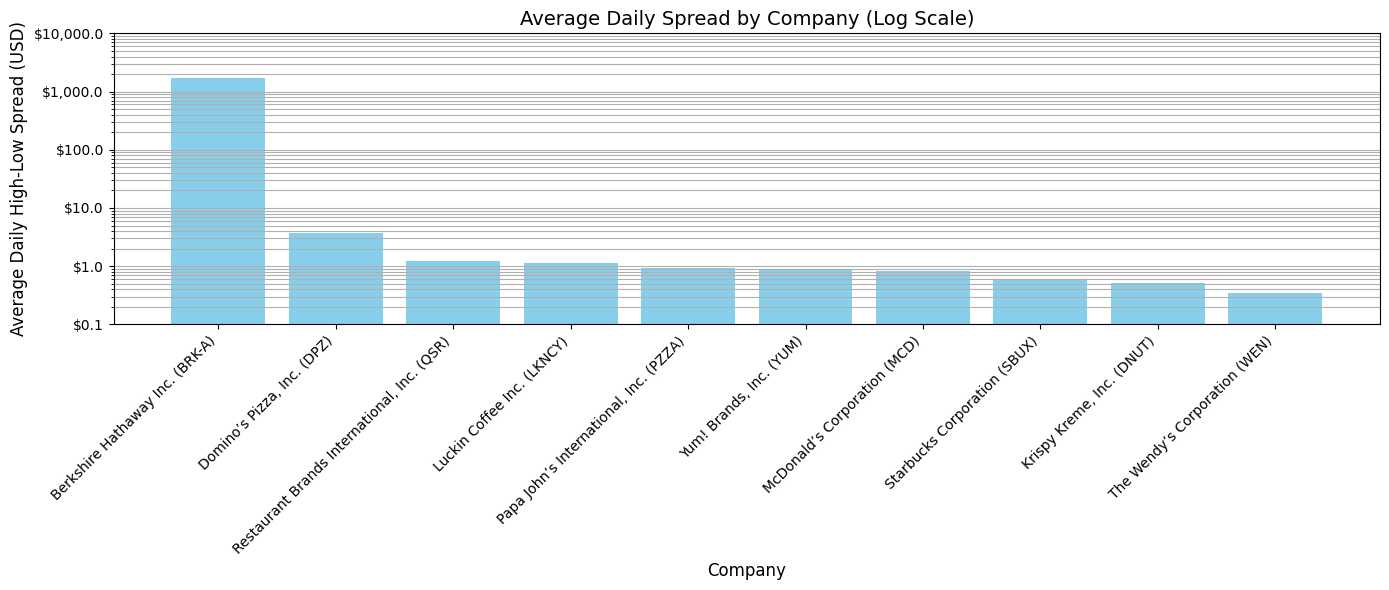

In [25]:
# Here we plotted the Average Daily Spread by Company
plt.figure(figsize=(14, 6))
plt.bar(spreads_df["Company"], spreads_df["Average Spread"], color="skyblue")

plt.title("Average Daily Spread by Company (Log Scale)", fontsize=14)
plt.xlabel("Company", fontsize=12)
plt.ylabel("Average Daily High-Low Spread (USD)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yscale('log')
plt.grid(axis="y", which="both")

# Here we adjusted the y-axis ticks for better readability
max_val = spreads_df["Average Spread"].max()
tick_values = [0.1, 1, 10, 100, 1000, 10000]
tick_values = [t for t in tick_values if t <= max_val * 10]
tick_labels = [f"${t:,.1f}" for t in tick_values]
plt.yticks(tick_values, tick_labels)
plt.tight_layout()
plt.show()




#### **Interpretation**:

In this exercise, we analyzed the daily price spreads for the 10 fast food companies. The spread was calculated as the difference between the daily high and low prices for each company. The average spread was then computed for each company and visualized using a bar chart with a log scale.

We chose a **bar chart** because it effectively compares the spread values across companies, making it easy to visualize the differences in magnitude between each company's average spread. We chosed to apply a  **logarithmic scale** to the y-axis because the spread values vary widely across companies—ranging from small values (e.g., less than $1 (WEN)) to very large values (e.g., over $1,000 (BRK-A)). With the log scale allowed us to represent these variations in a way that maintains clarity and avoids distorting smaller values, which would otherwise be overshadowed by the larger ones.

The chart reveals that **Berkshire Hathaway Inc. (BRK-A)** has the highest spread due to its extremely high stock price, where even small percentage changes translate into large dollar amounts. Companies like **Domino's Pizza Inc. (DPZ)** and **Restaurant Brands International Inc. (QSR)** show moderate spreads, likely reflecting sector-specific volatility. In contrast, companies such as **The Wendy’s Corporation (WEN)** and **Krispy Kreme Inc. (DNUT)** have much smaller spreads, indicating stable prices and lower volatility.

Finally, we used a bar chart with a log scale highlights because both subtle differences in smaller spreads and dramatic differences in larger spreads, ensuring that all data points are represented proportionately and are easy to interpret. Providing a clear understanding of the relationship between average spreads and company characteristics, such as stock price levels, market activity, and sector-specific dynamics.